In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/5sec_50%overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_MRMR_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_MRMR_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_MRMR_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (829483, 16)
Val:   (104736, 16)
Test:  (105176, 16)


In [5]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (829483, 15)
y_train: (829483,)
X_val:   (104736, 15)
y_val:   (104736,)
X_test:  (105176, 15)
y_test:  (105176,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/data/SBP_MRMR_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(9271840, 17)
    vpg_iqr  ppg_zero_crossing_rate  apg_energy_variance  ppg_energy_kurtosis  \
0  1.749678                     0.0            -0.016827            -1.676603   
1  1.591203                     0.0            -0.016703            -1.635194   
2  1.771377                     0.0            -0.016579            -1.592502   
3  2.261320                     0.0            -0.016630            -1.569943   
4  2.276123                     0.0            -0.016865            -1.729946   

   vpg_mean   ppg_std  vpg_median  apg_energy_kurtosis  apg_median  apg_mean  \
0 -0.426272 -0.150627   -2.836776             0.052821   -1.594106 -1.394359   
1 -1.517758  0.148760   -3.109268            -0.011578   -1.409760 -0.163156   
2 -0.861609  0.573230   -3.246622            -0.081655   -1.349989  0.600172   
3  1.064260  0.501888   -3.144472            -0.100477   -1.210387  1.400409   
4  1.924317  0.408461   -2.776534            -0.117246   -1.434122 -0.373121   

   apg_zero_crossi

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.48465074023241
SBP max: 199.3622907516529
SBP mean: 129.94175380628658
SBP std: 22.028076535061036
SBP > 80: 828714
SBP > 90: 816812
SBP > 100: 768831


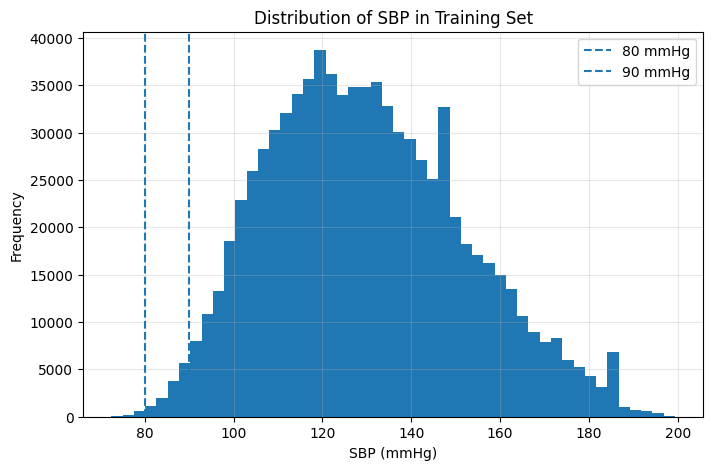

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 22.0099
MSE : 484.4355
R²  : 0.0823
MAE : 17.6838


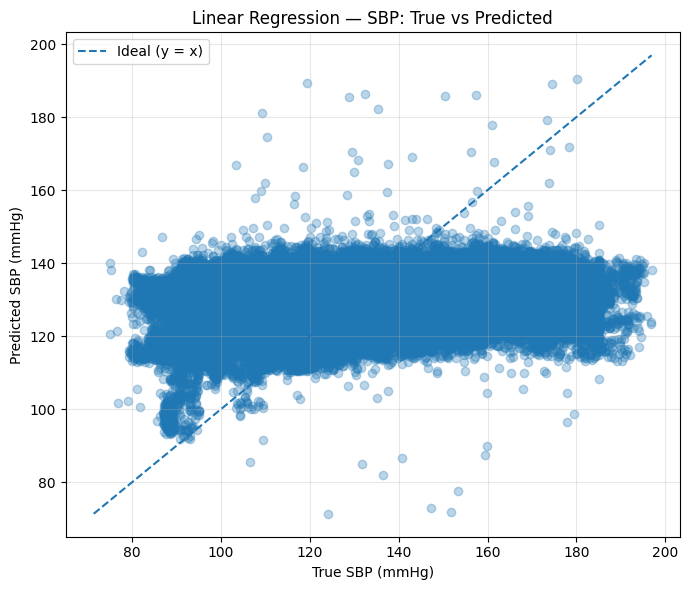

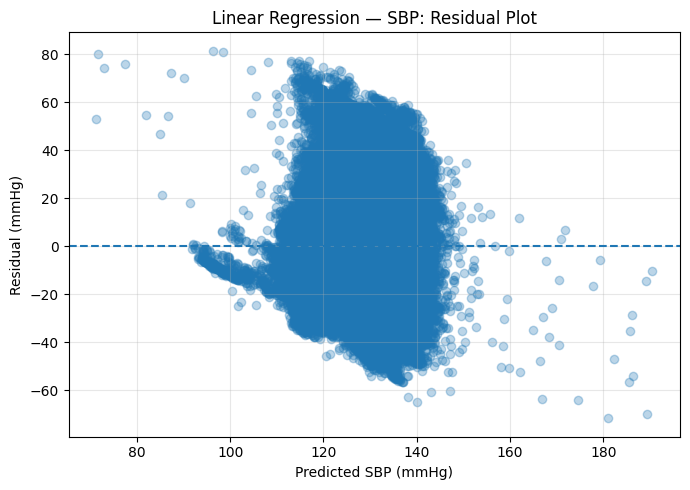

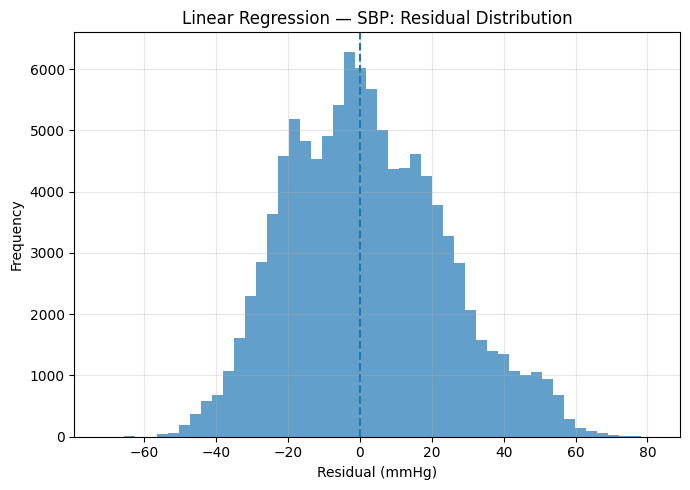

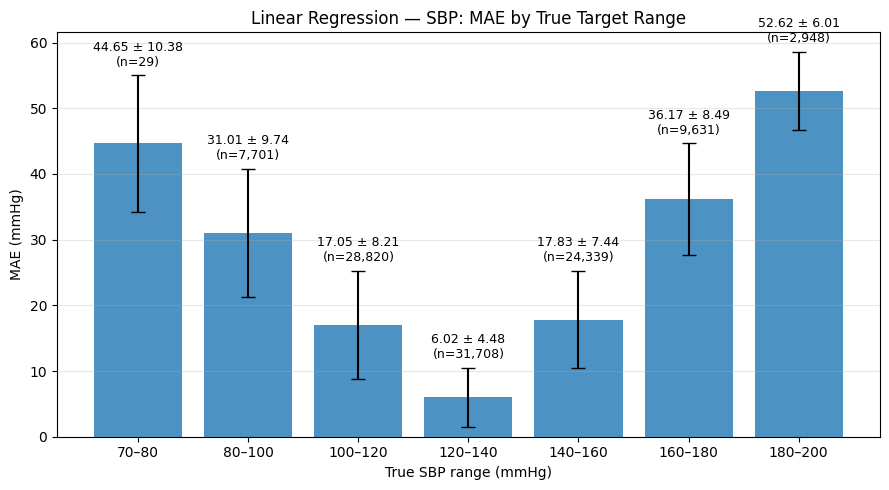

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 95.2624
MSE : 9074.9327
R²  : -20.2328
MAE : 27.0444


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


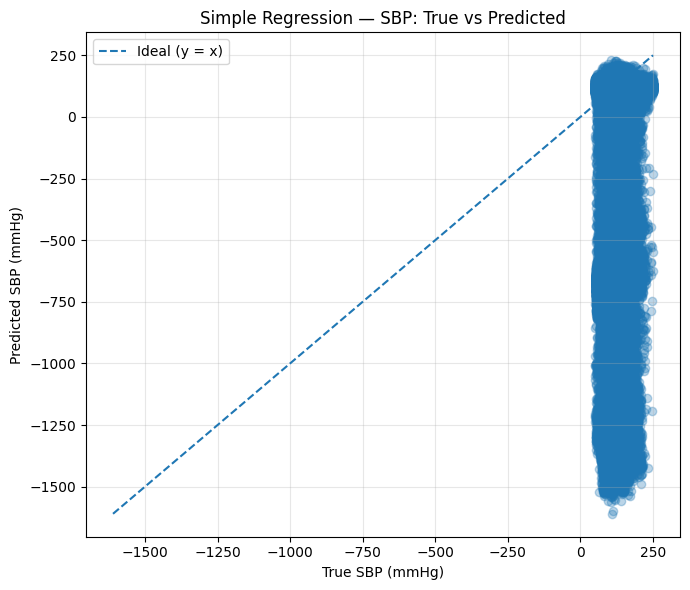

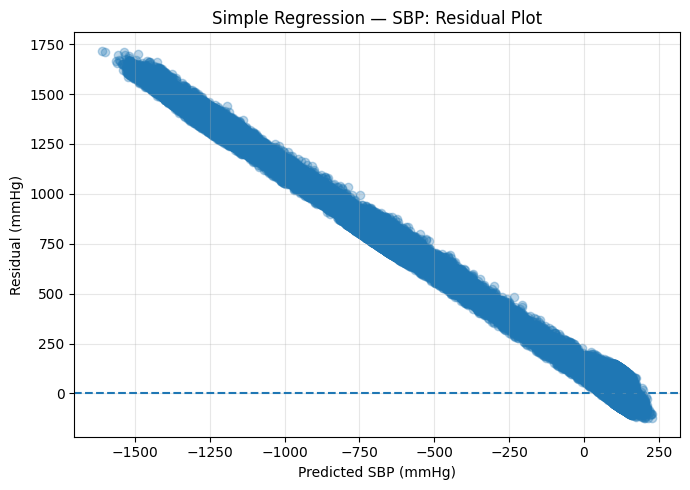

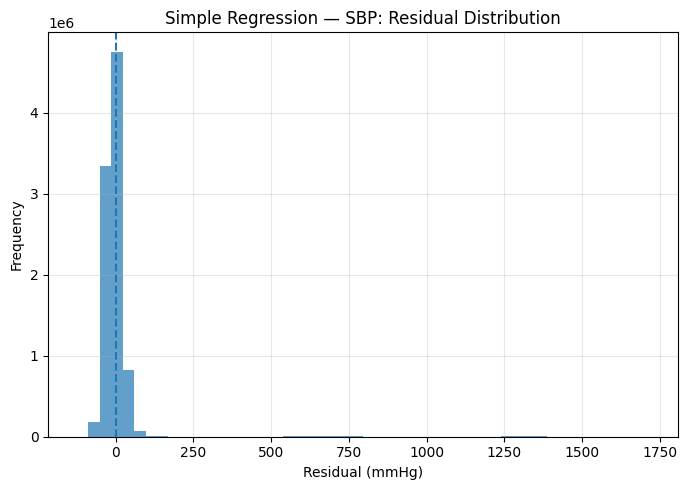

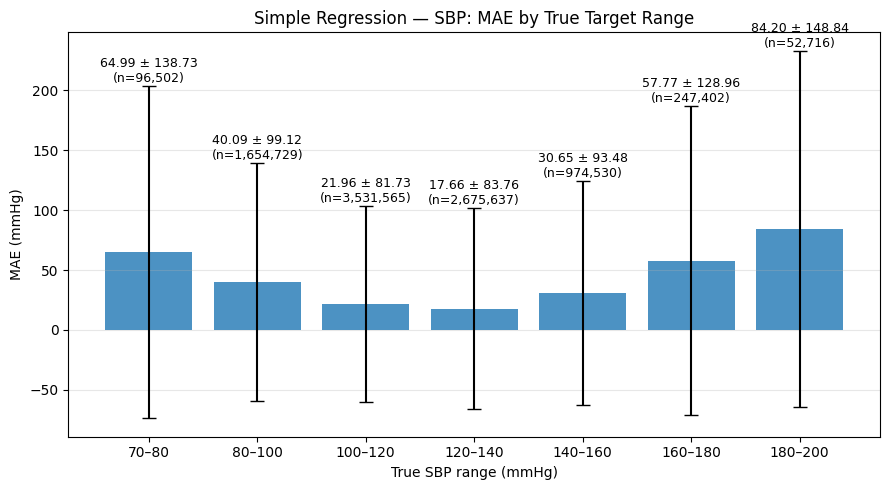

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 21.3157
MSE : 454.3580
R²  : 0.1393
MAE : 17.0657


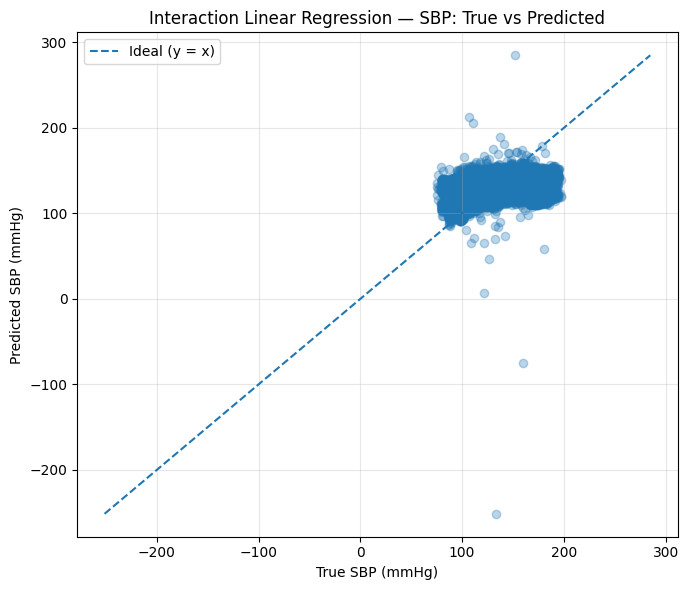

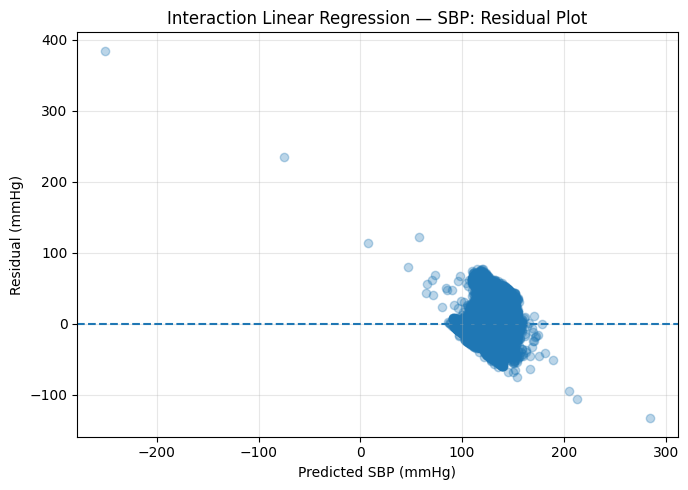

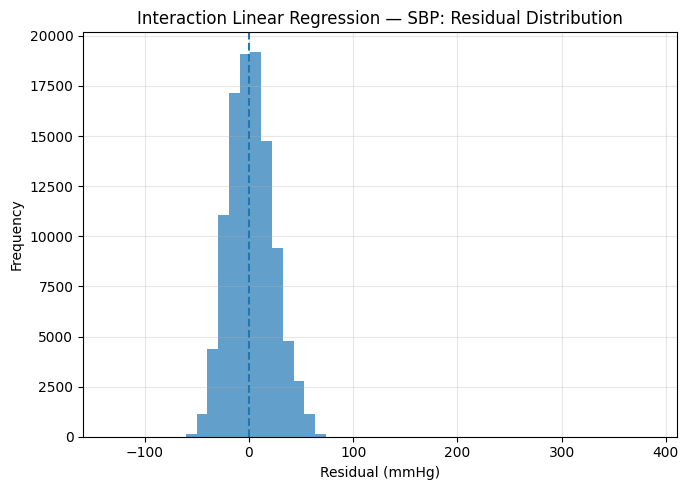

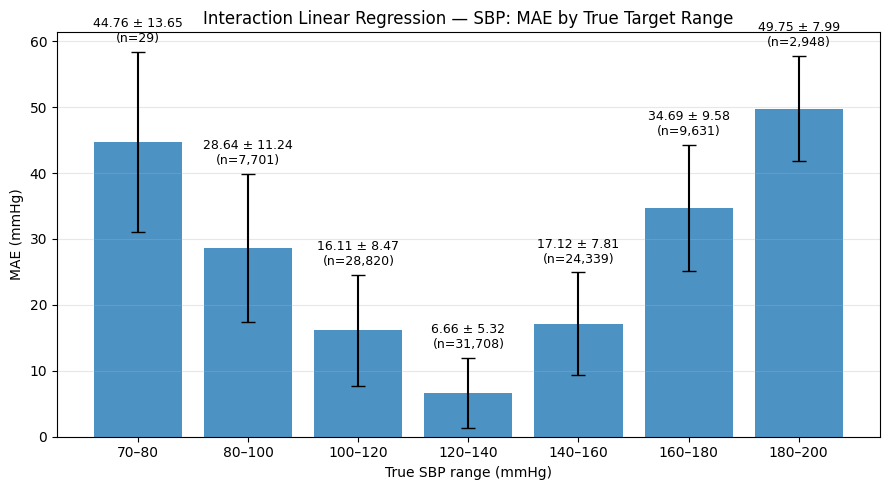

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 1977.6296
MSE : 3911018.9993
R²  : -9149.6748
MAE : 242.0248


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


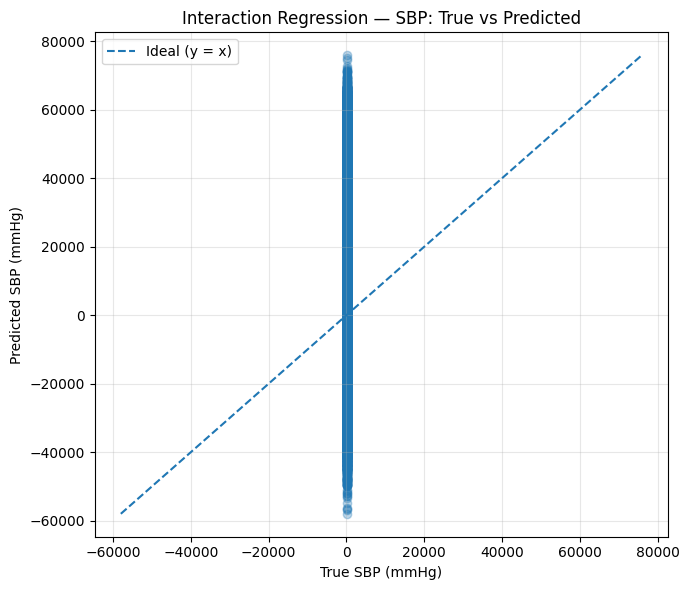

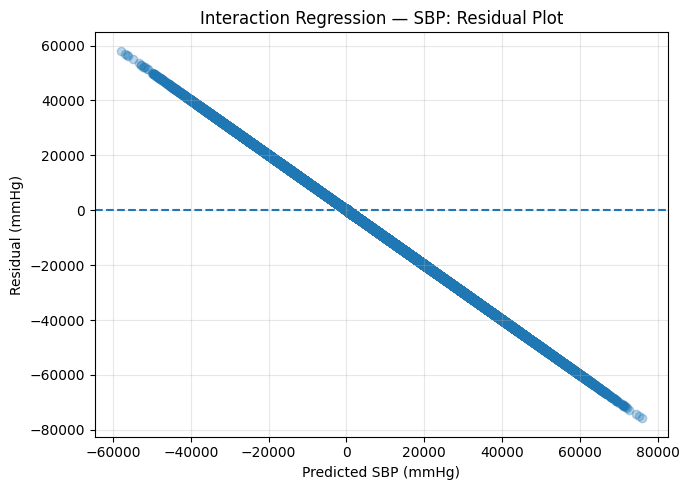

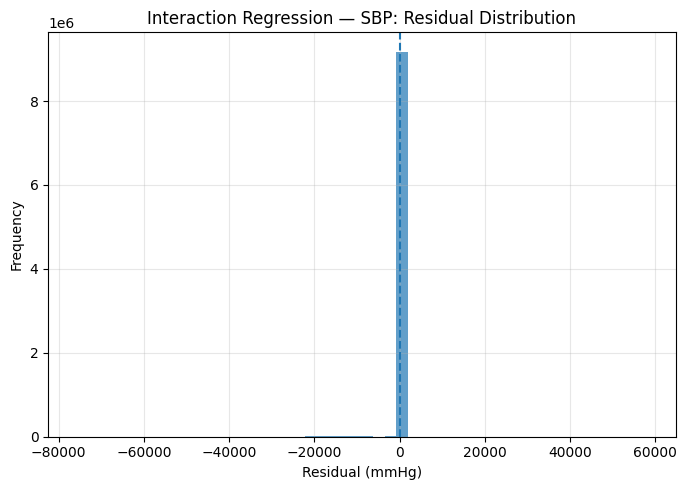

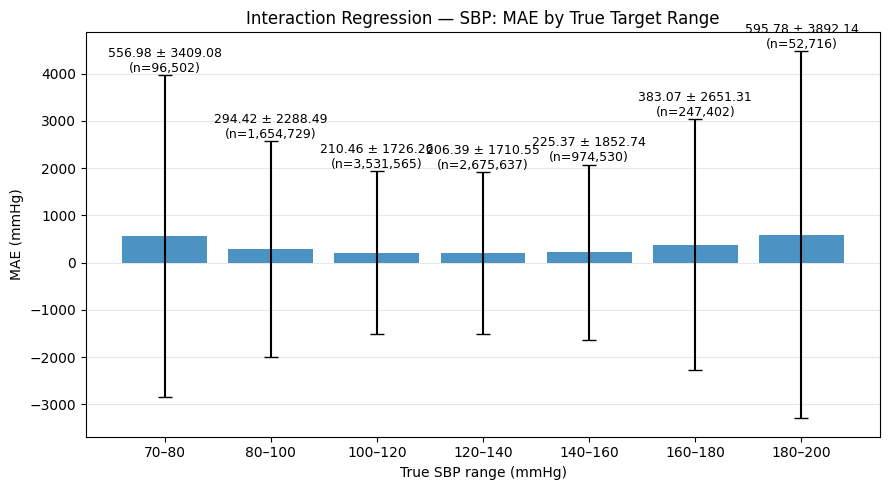

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — SBP
----------------------------------------
RMSE: 22.0380
MSE : 485.6721
R²  : 0.0799
MAE : 17.6797


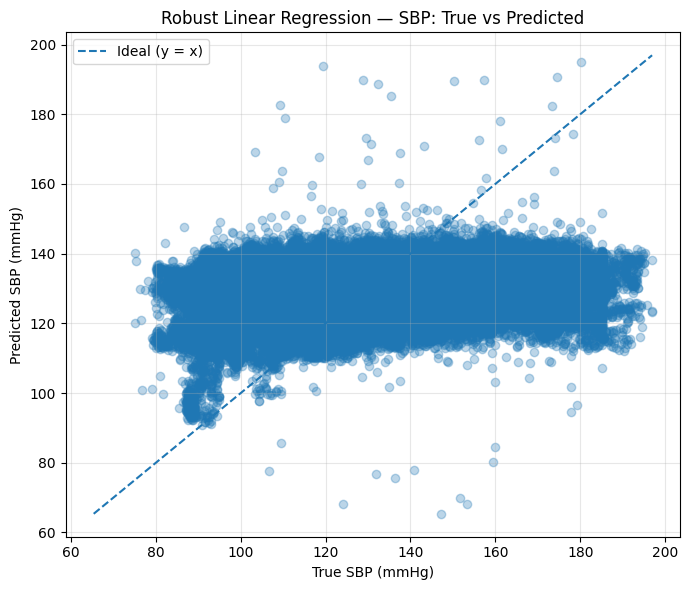

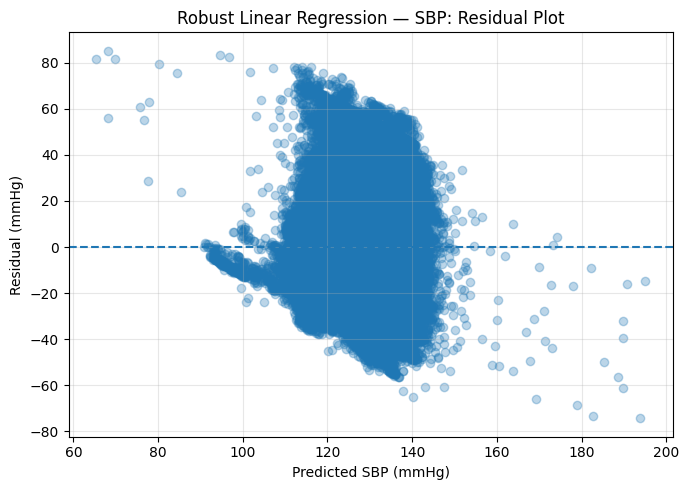

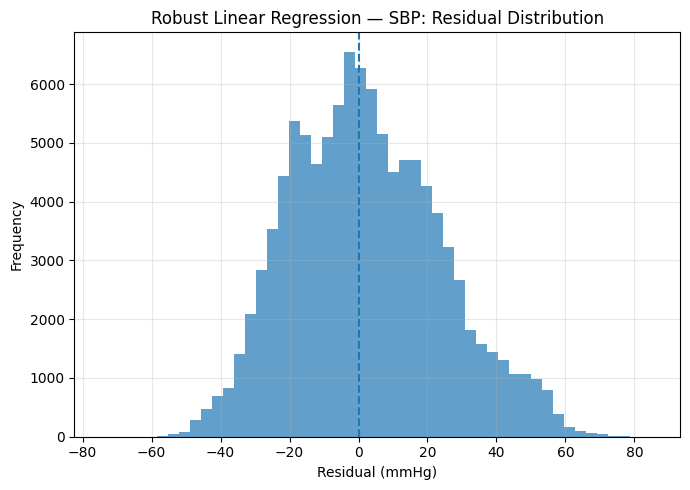

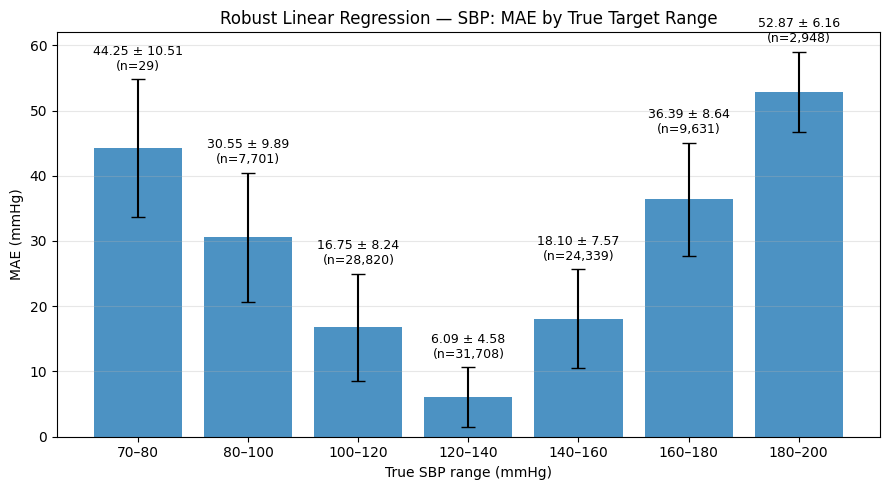

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 97.0330
MSE : 9415.3971
R²  : -21.0294
MAE : 27.4574


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


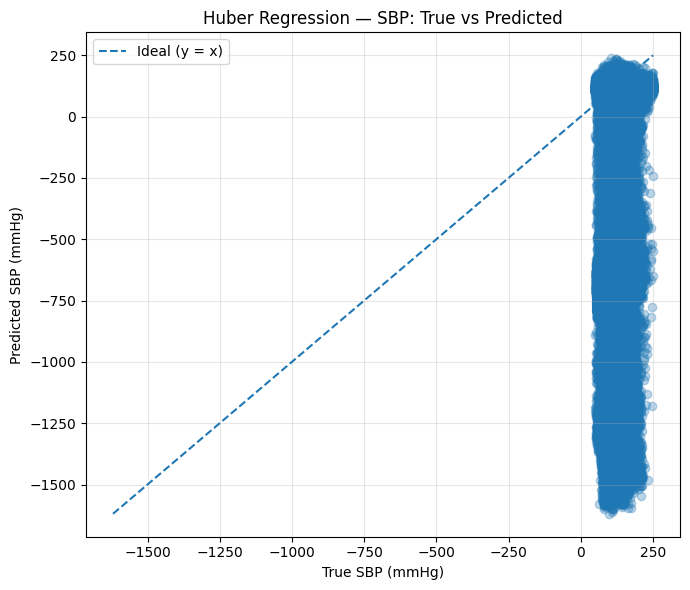

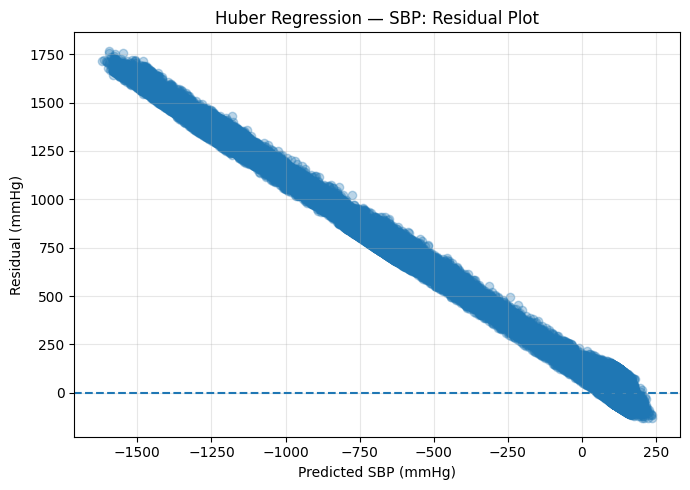

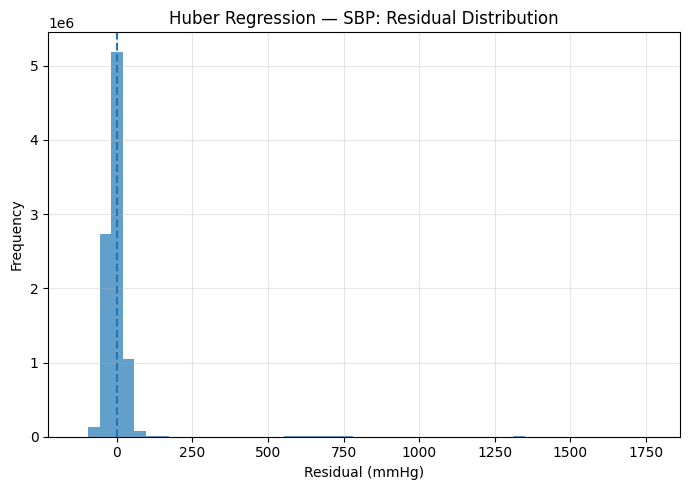

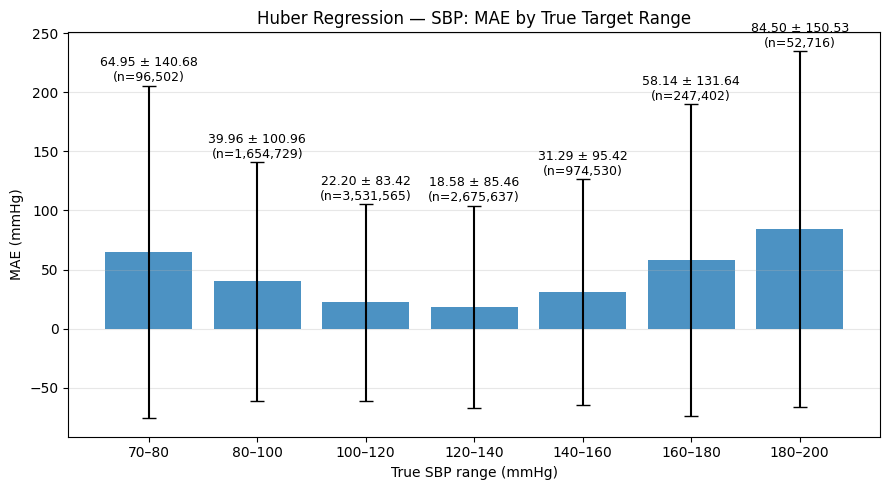

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — SBP
--------------------------------
RMSE: 20.1855
MSE : 407.4532
R²  : 0.2281
MAE : 15.3340


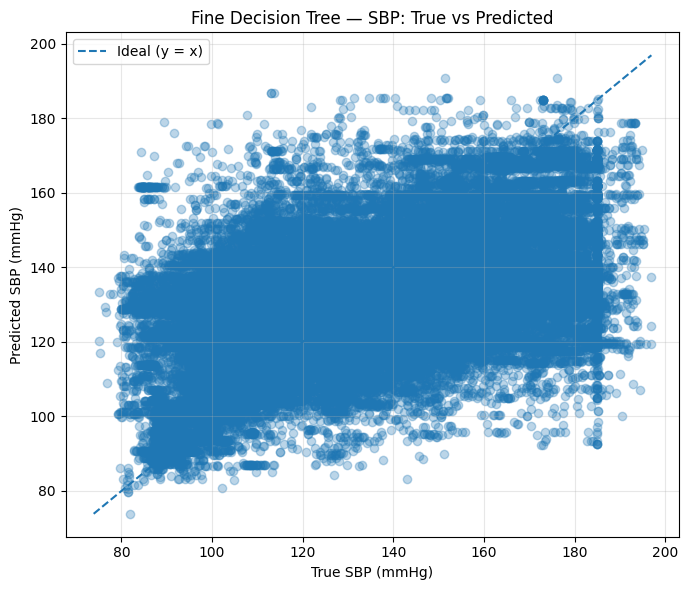

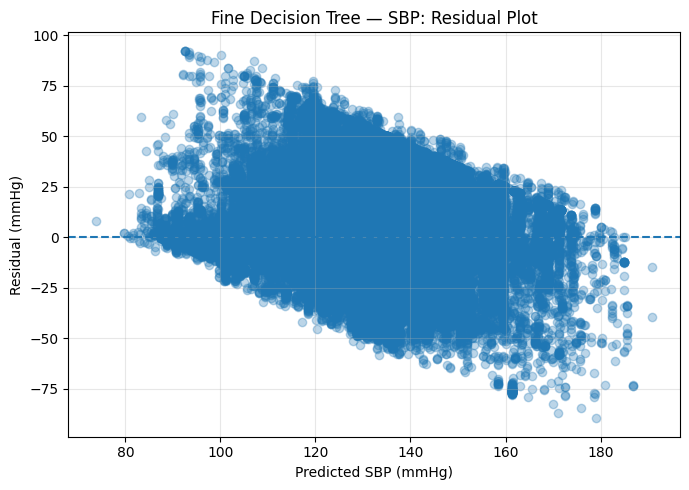

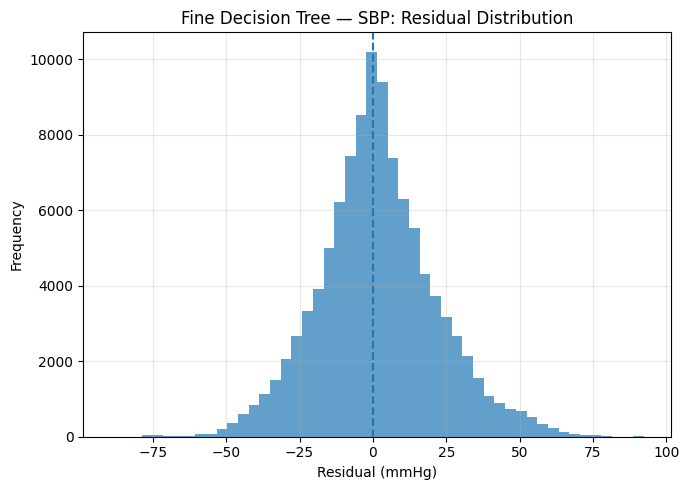

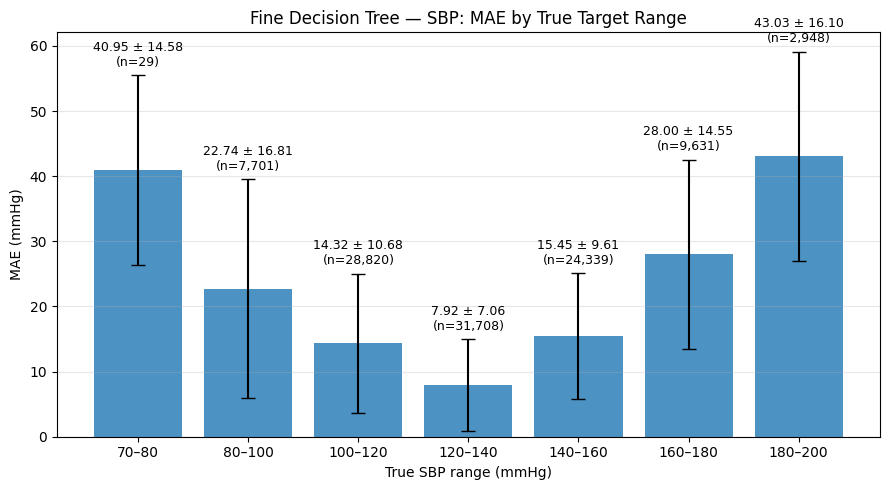

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 27.7335
MSE : 769.1455
R²  : -0.7996
MAE : 22.7913


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


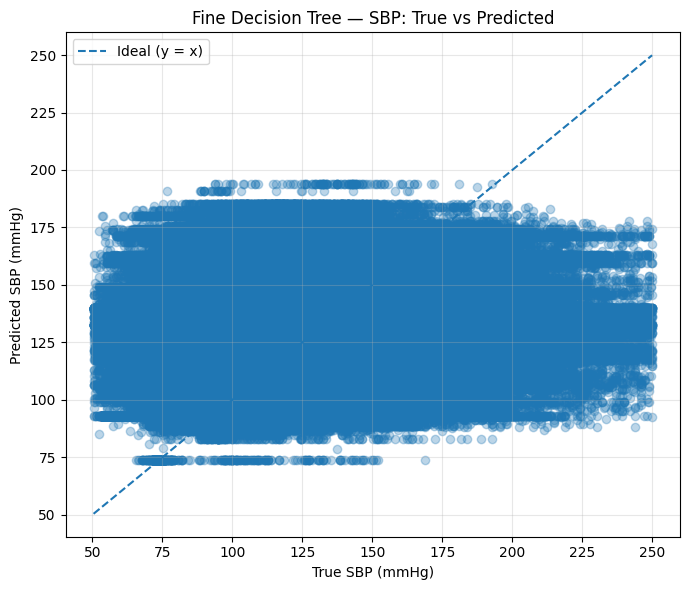

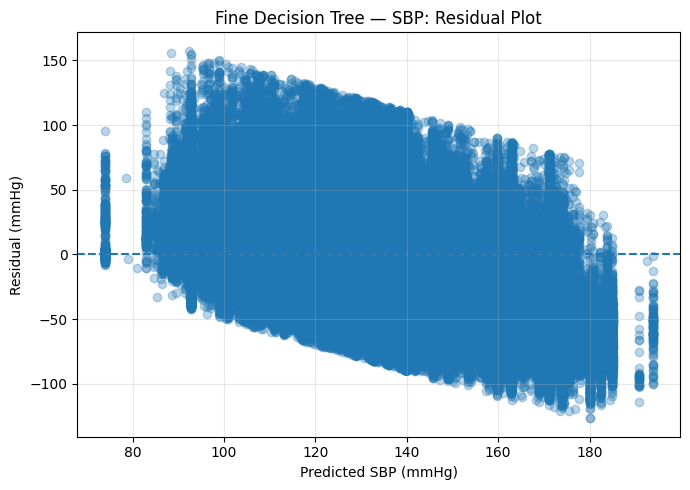

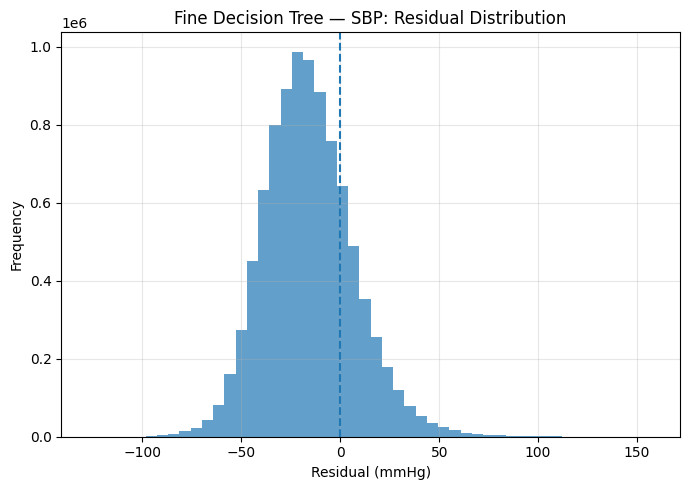

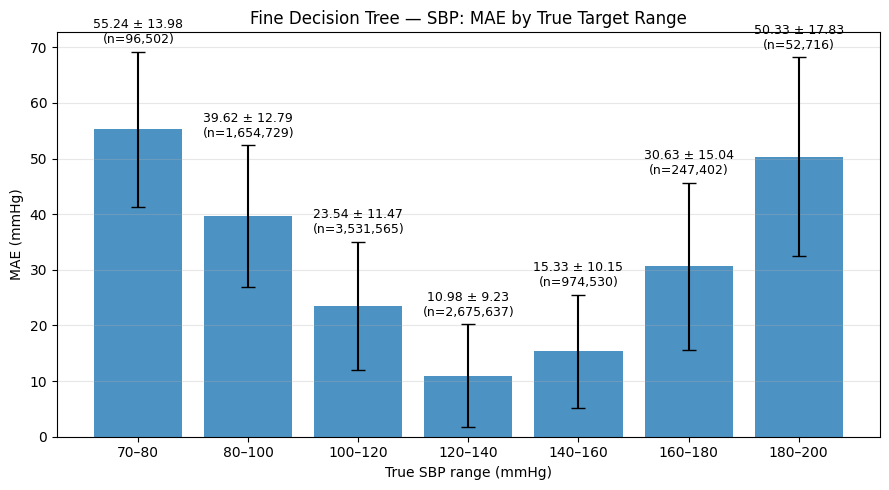

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — SBP
----------------------------
RMSE: 17.6023
MSE : 309.8411
R²  : 0.4130
MAE : 13.1990


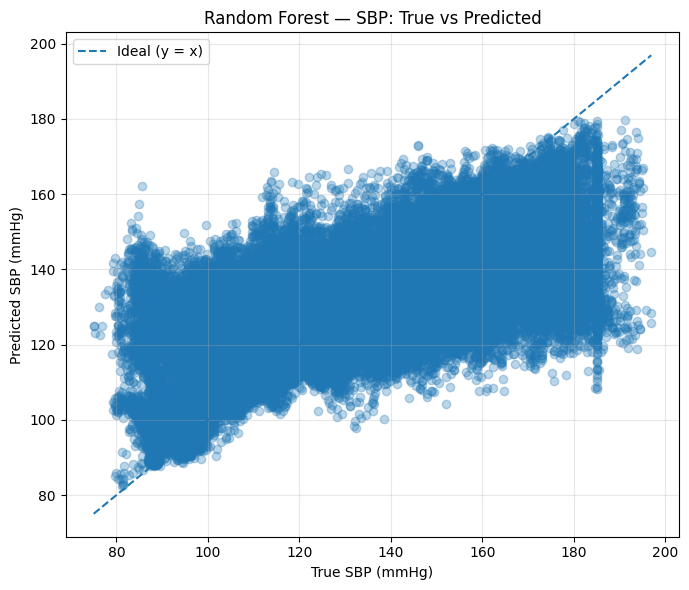

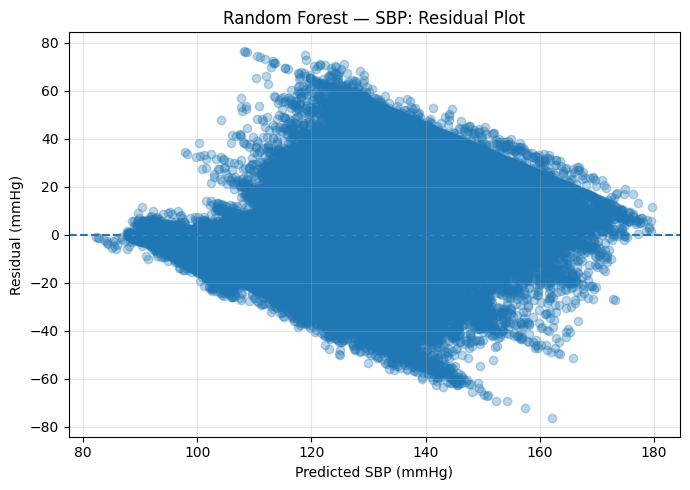

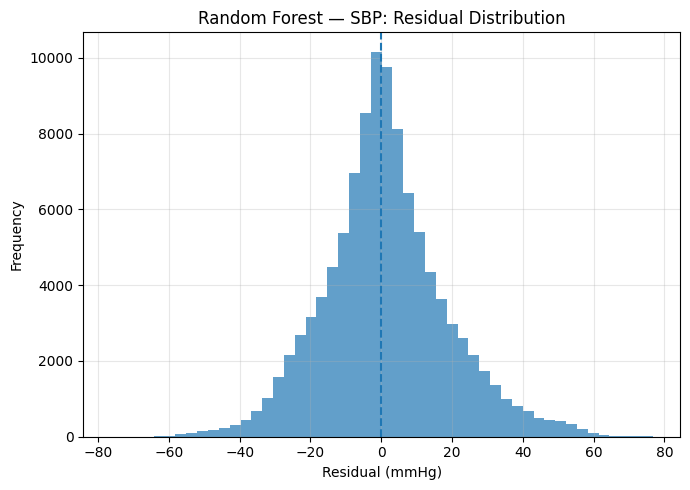

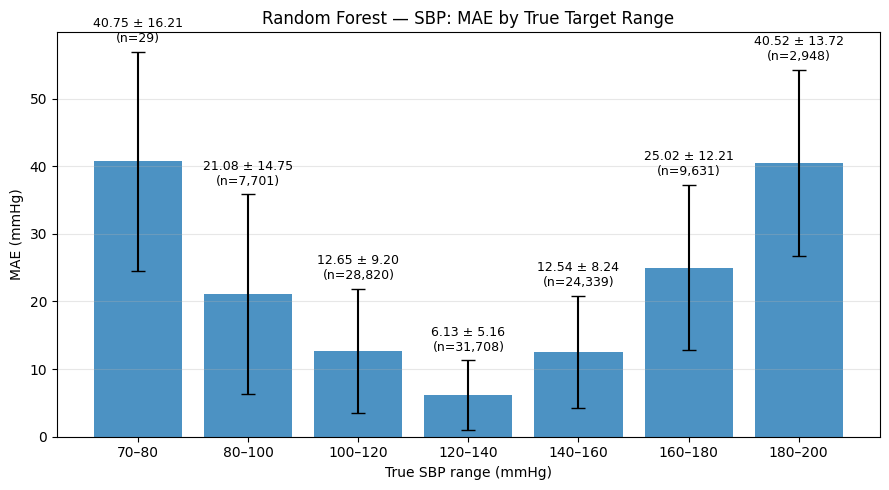

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 25.7118
MSE : 661.0977
R²  : -0.5468
MAE : 21.3444


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


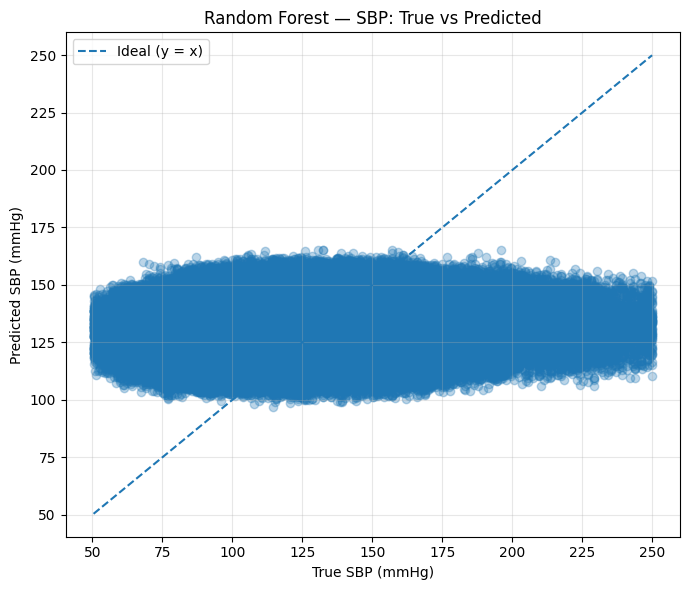

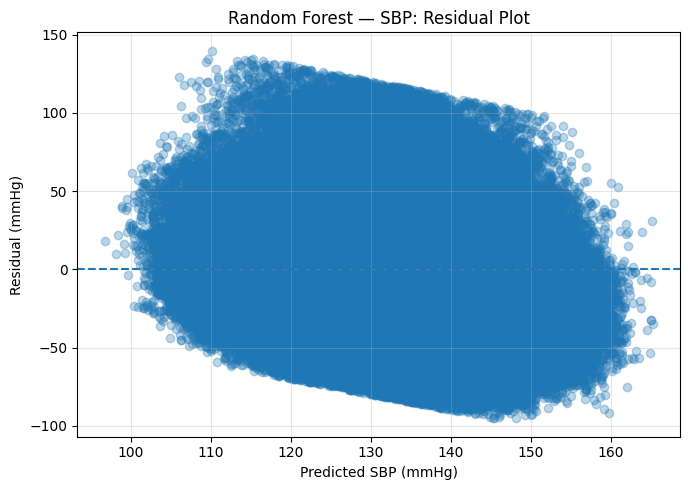

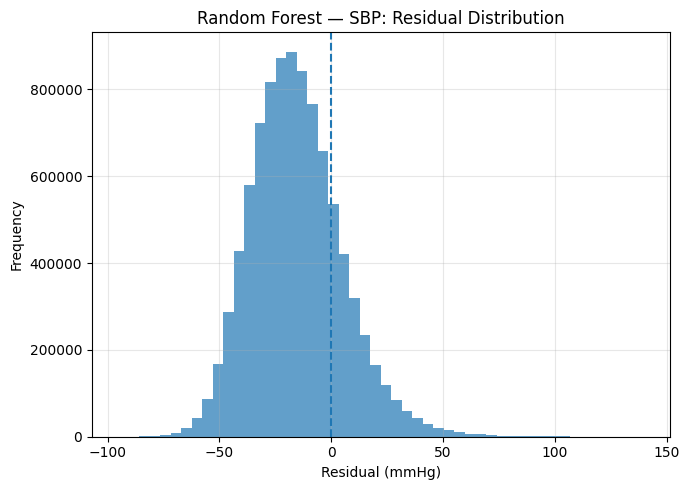

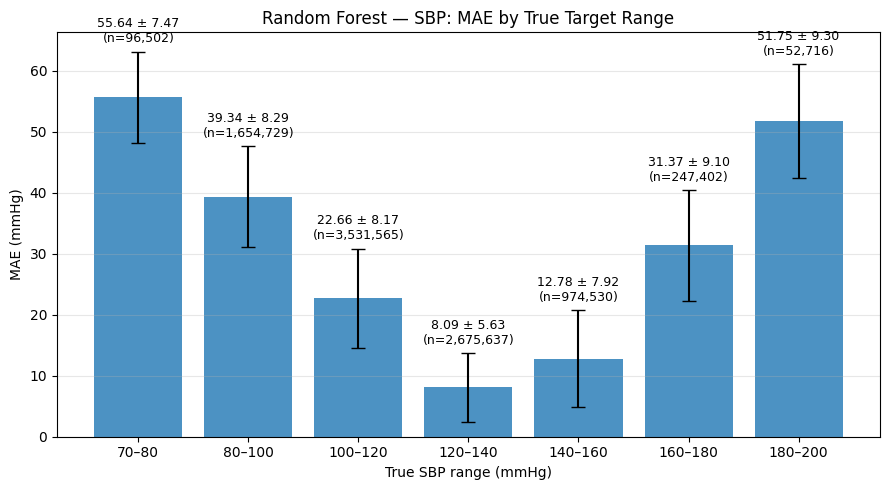

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — SBP
--------------------------------------
RMSE: 17.5918
MSE : 309.4712
R²  : 0.4137
MAE : 13.0490


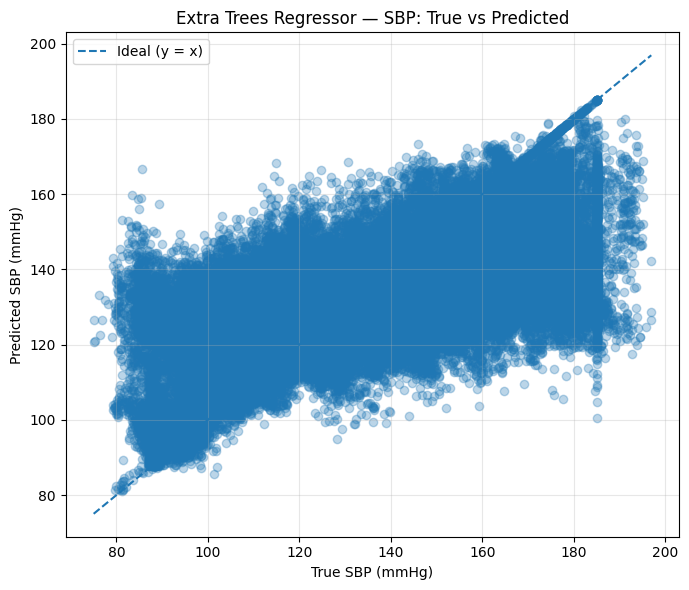

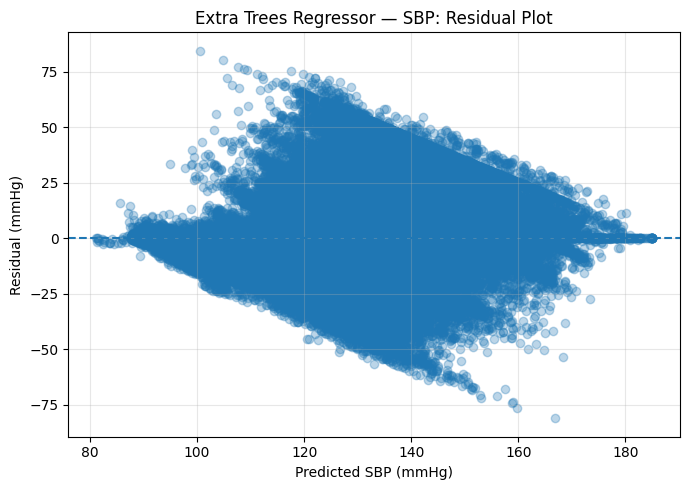

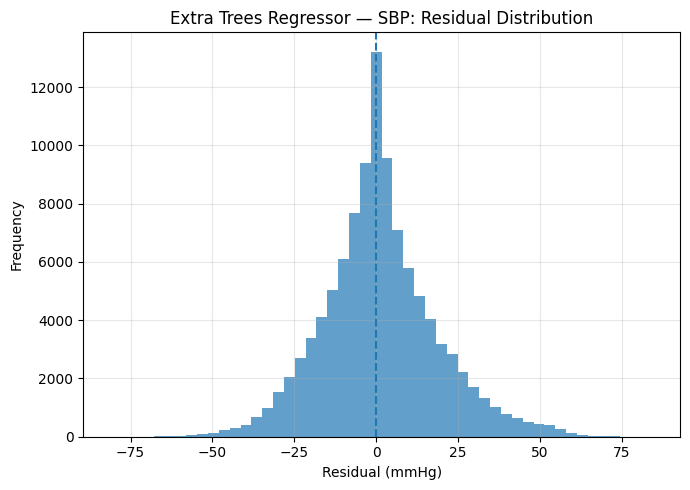

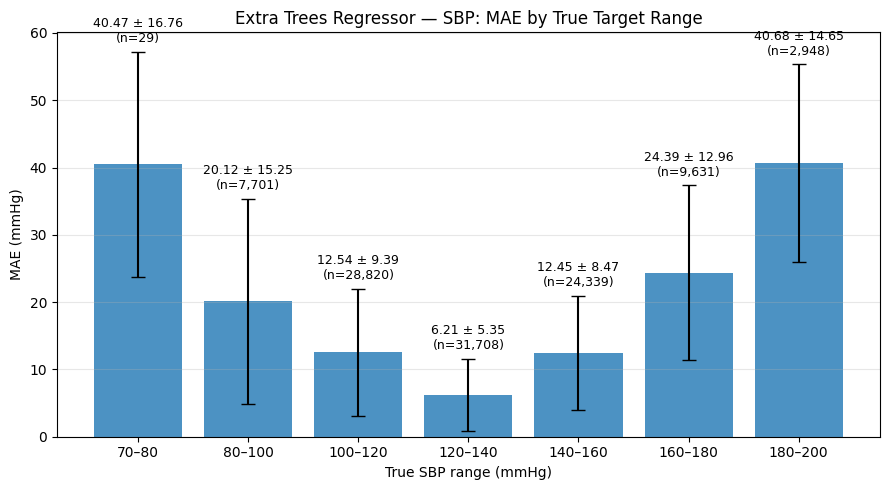

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.9620
MSE : 726.9480
R²  : -0.7009
MAE : 22.5517


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


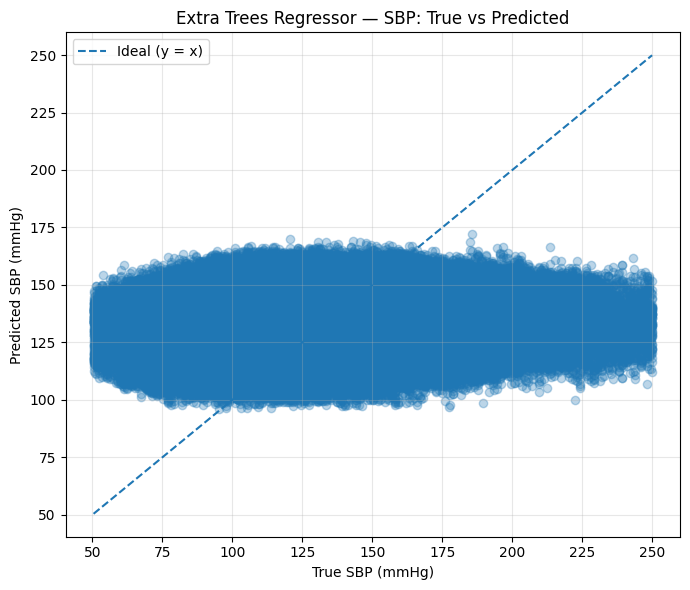

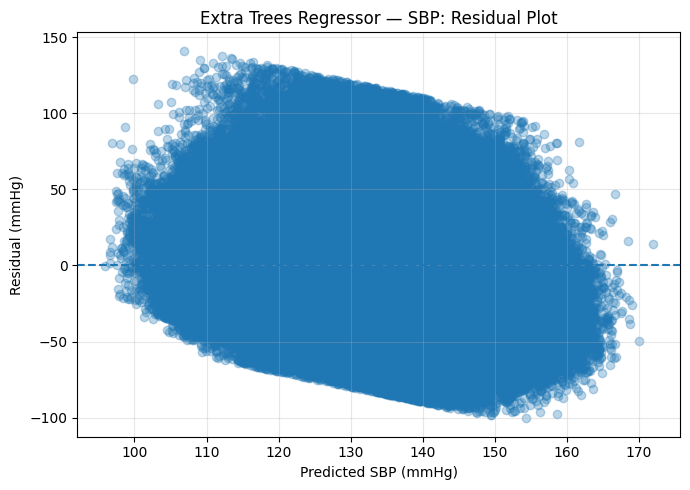

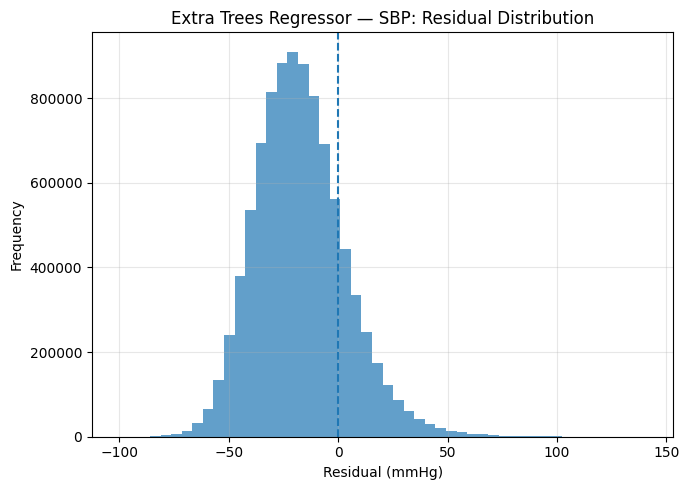

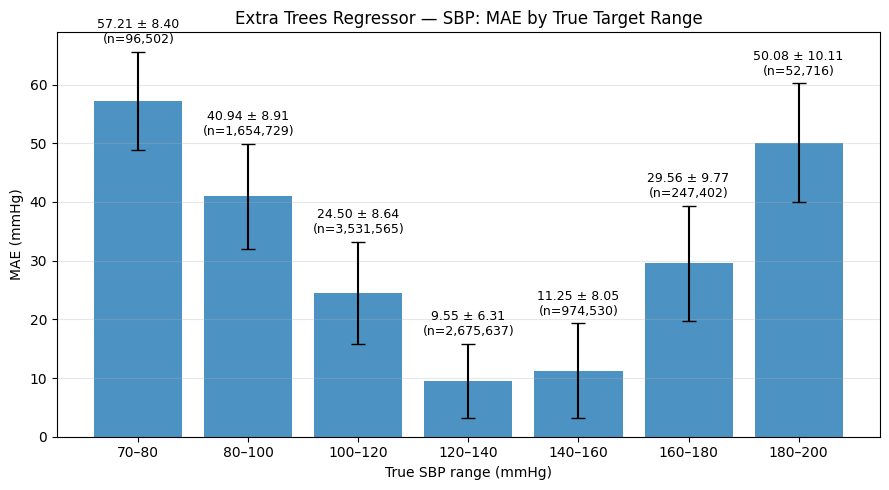

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — SBP
---------------------
RMSE: 18.8908
MSE : 356.8631
R²  : 0.3240
MAE : 14.6928


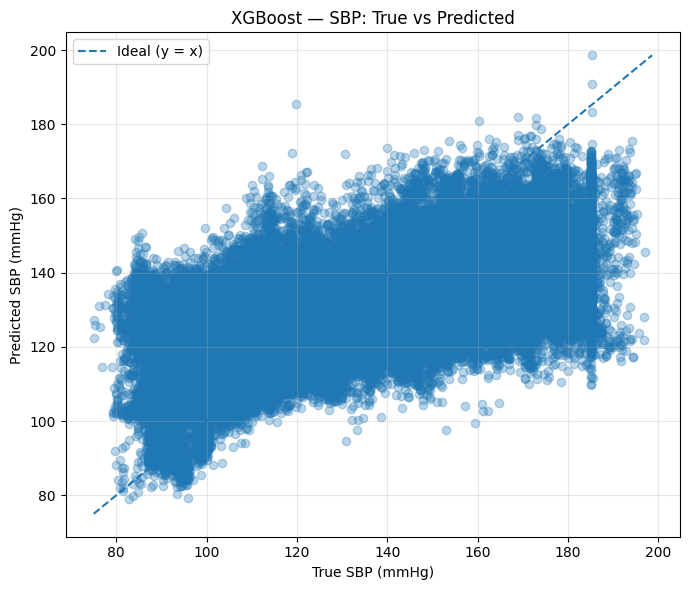

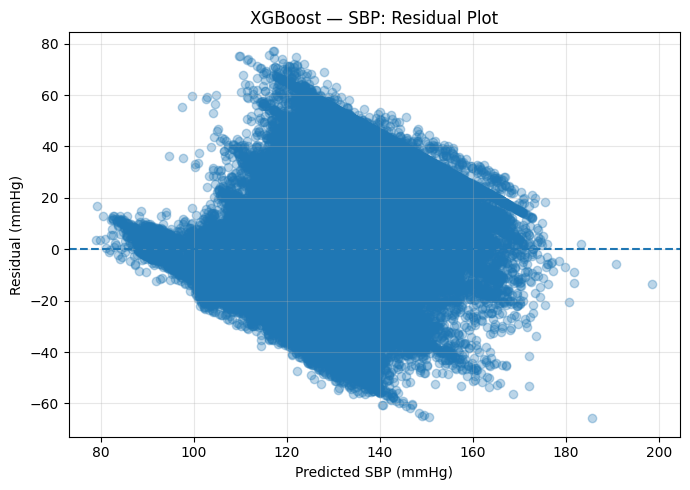

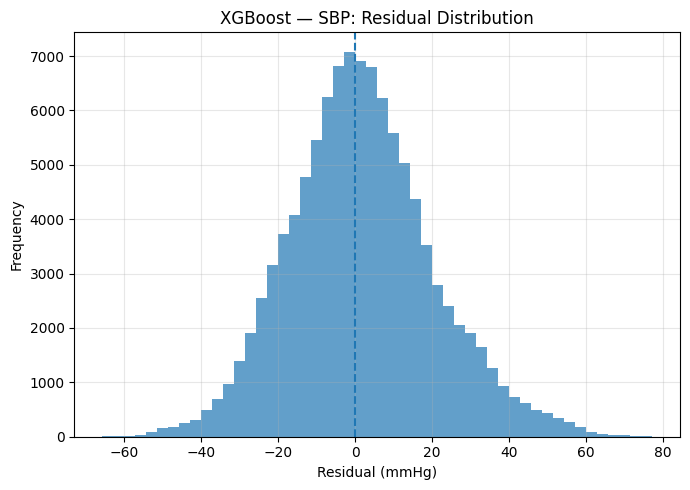

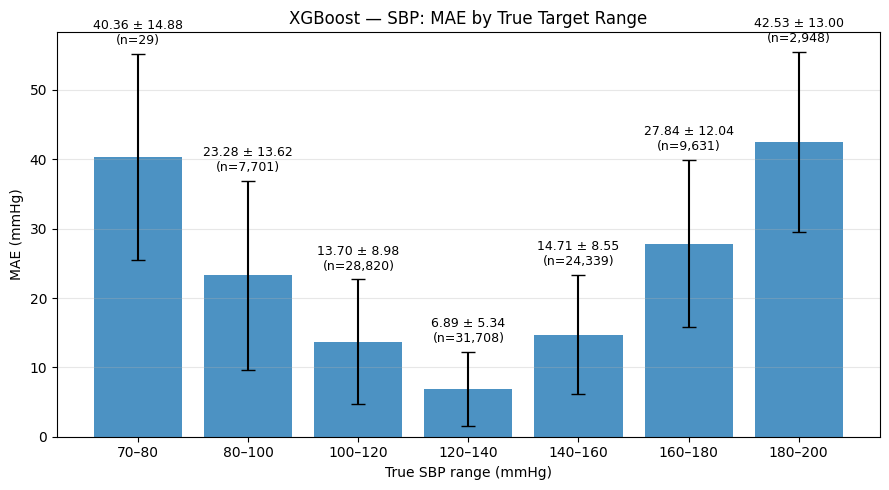

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 30.1670
MSE : 910.0502
R²  : -1.1293
MAE : 25.3181


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


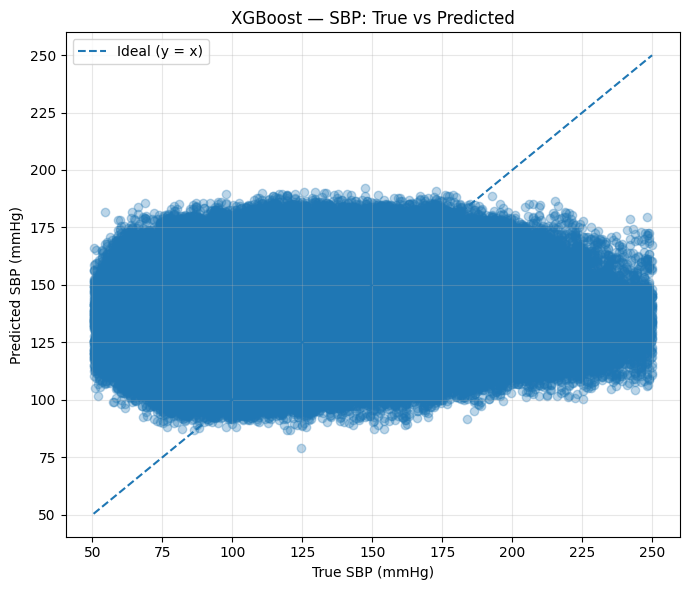

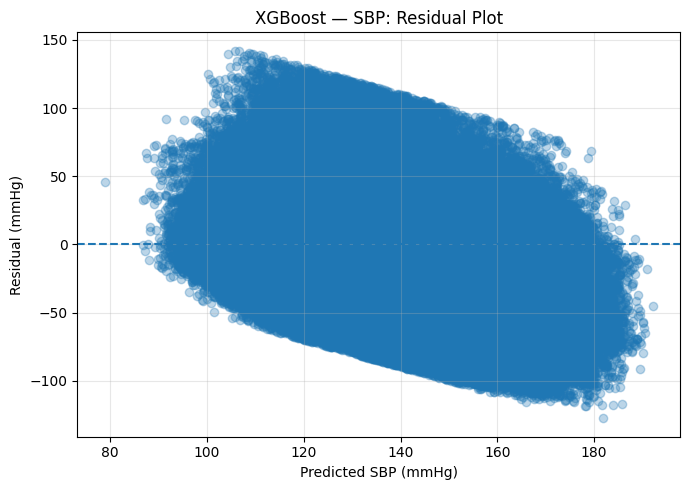

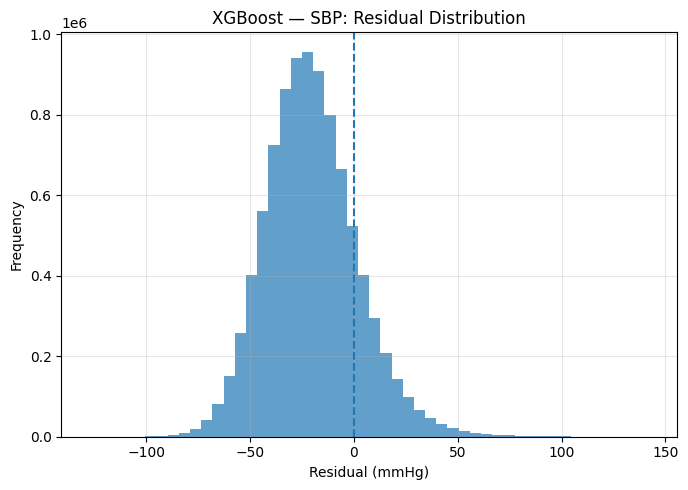

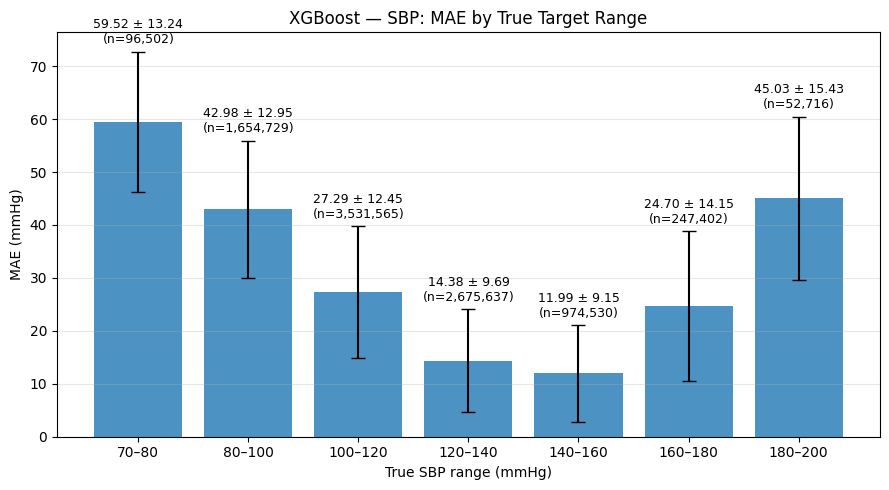

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=  25.2s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=  49.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 1.0min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time= 1.3min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 1.7min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 2.5min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 2.0min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time= 1.3min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time= 1.8min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time= 2.1min
[CV] END learning_rate=0.05, max_depth=10, n_estim

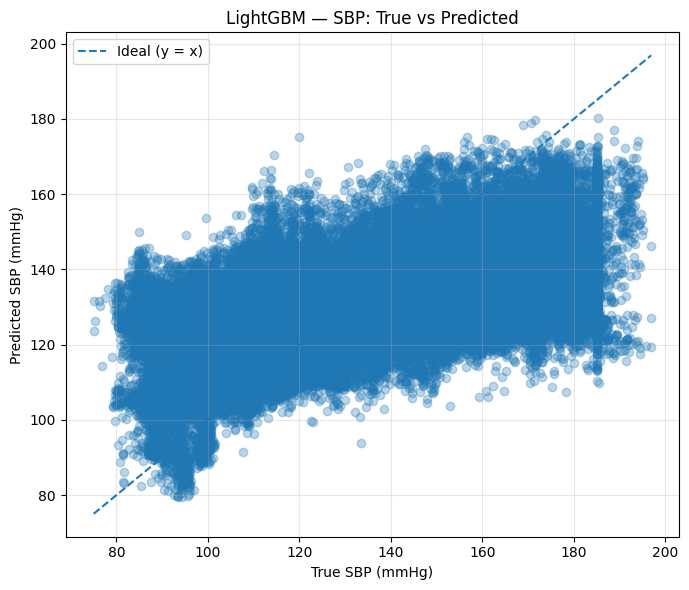

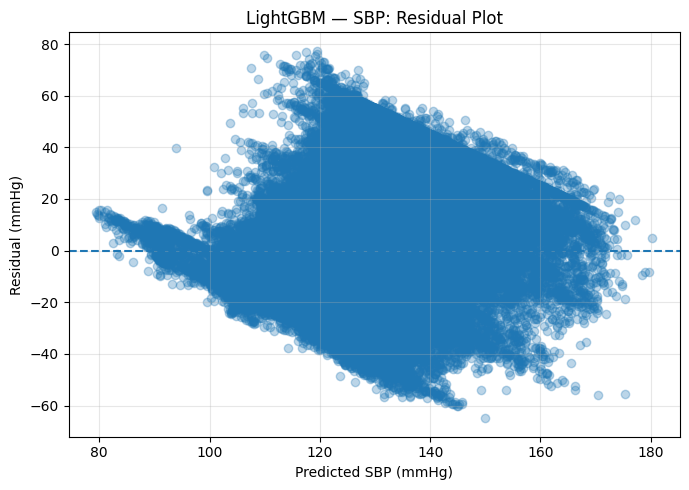

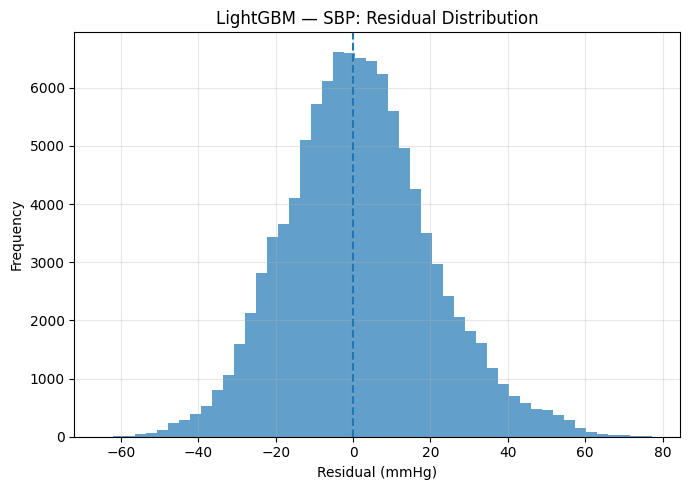

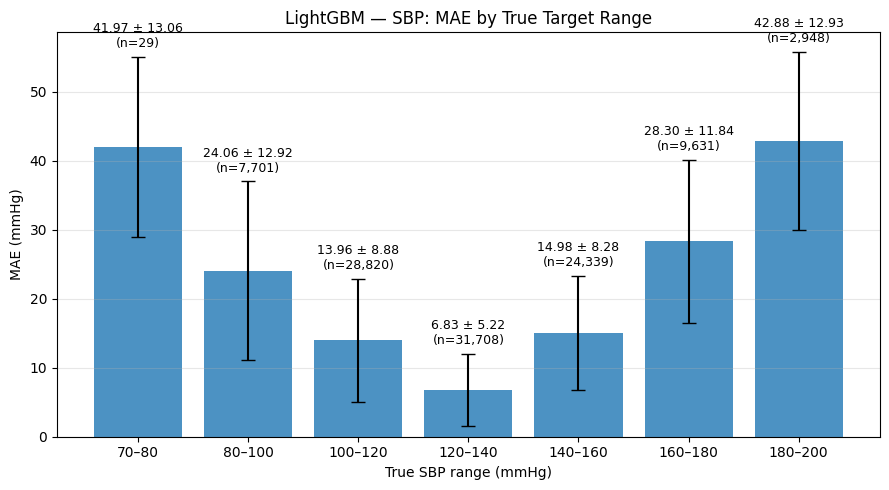

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.6986
MSE : 712.8156
R²  : -0.6678
MAE : 22.2055


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


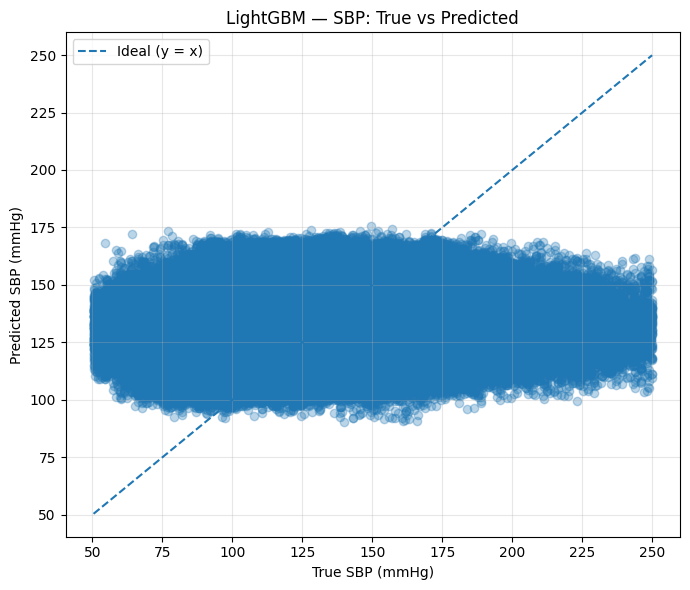

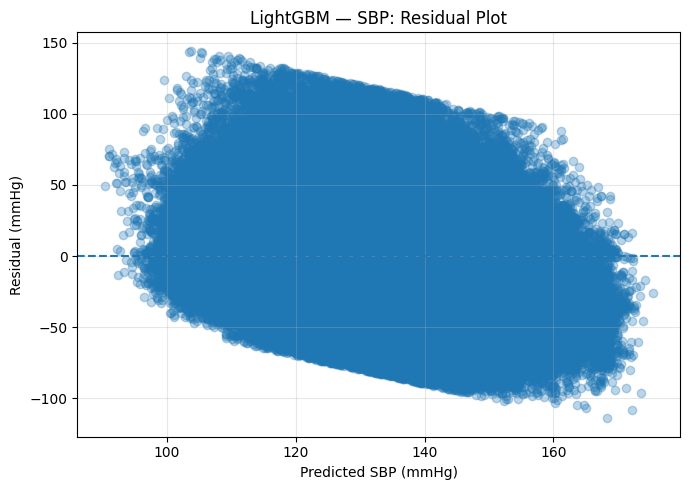

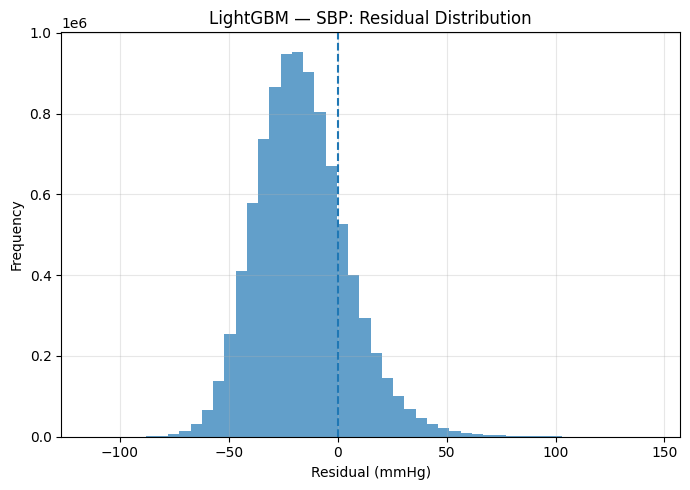

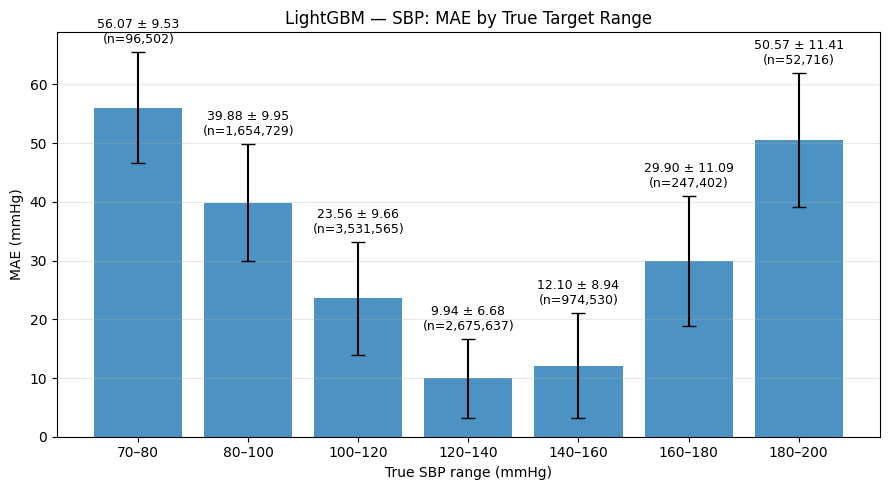

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Best parameters:
{'kernel': 1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — SBP
--------------------------------
RMSE: 20.5894
MSE : 423.9241
R²  : 0.1969
MAE : 16.2626


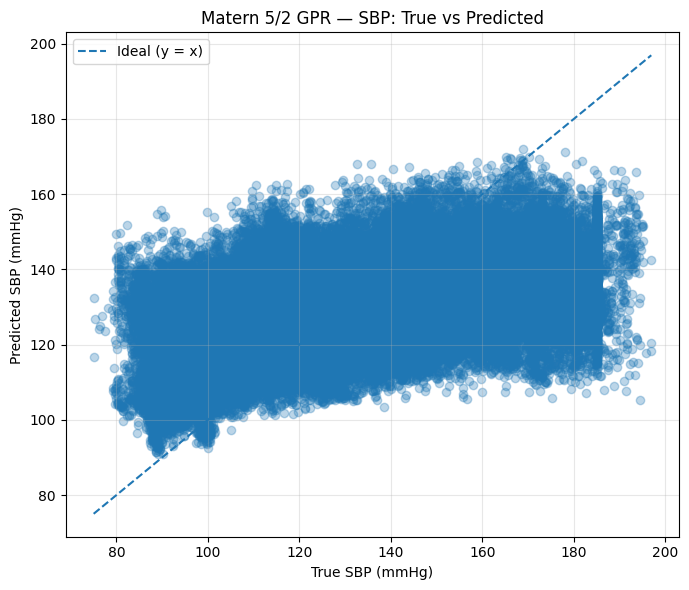

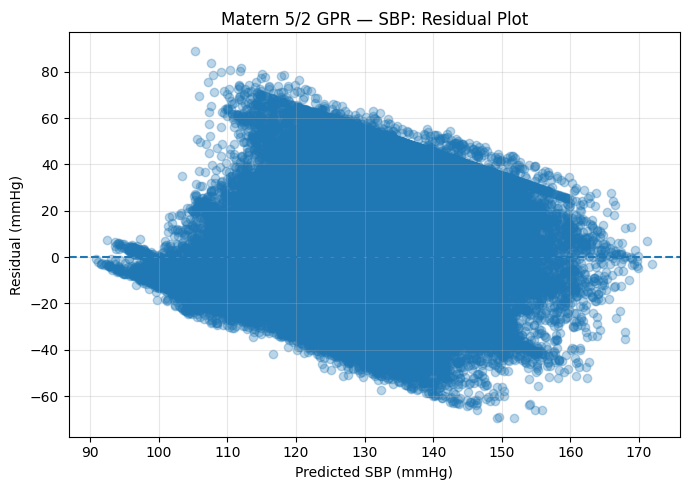

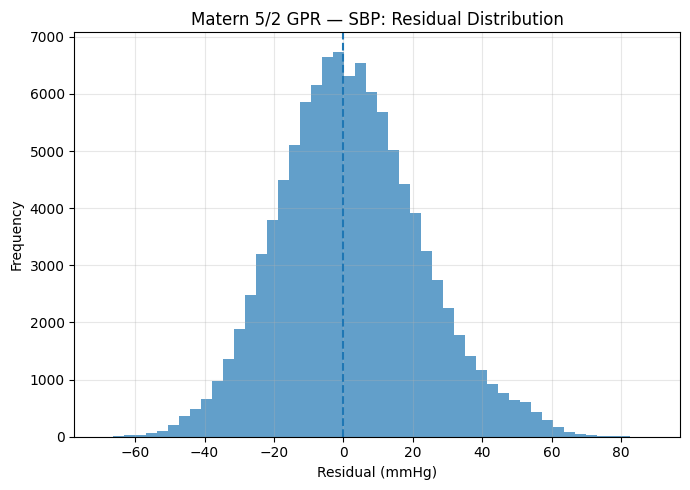

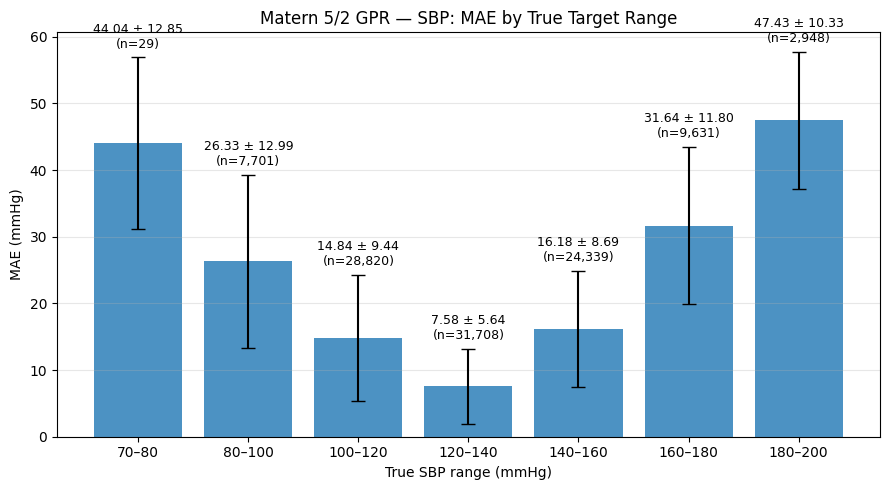

In [27]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 23.8760
MSE : 570.0621
R²  : -0.3338
MAE : 19.6548


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


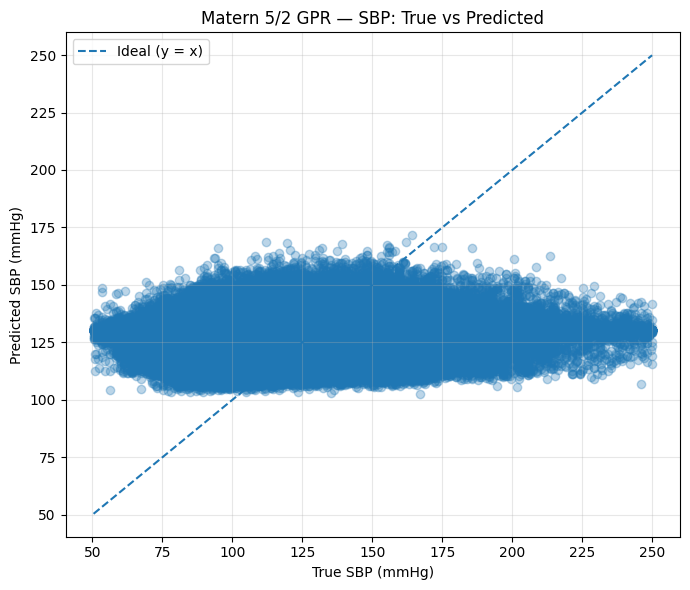

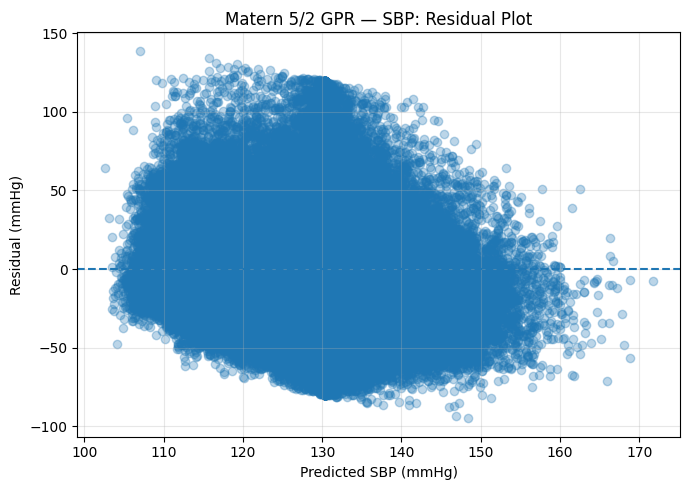

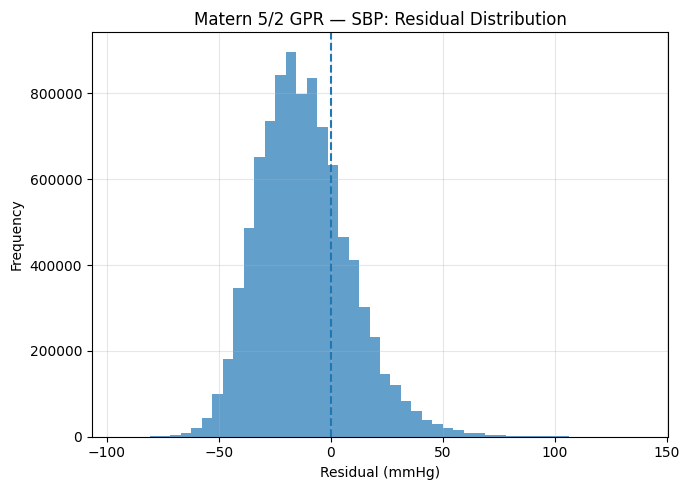

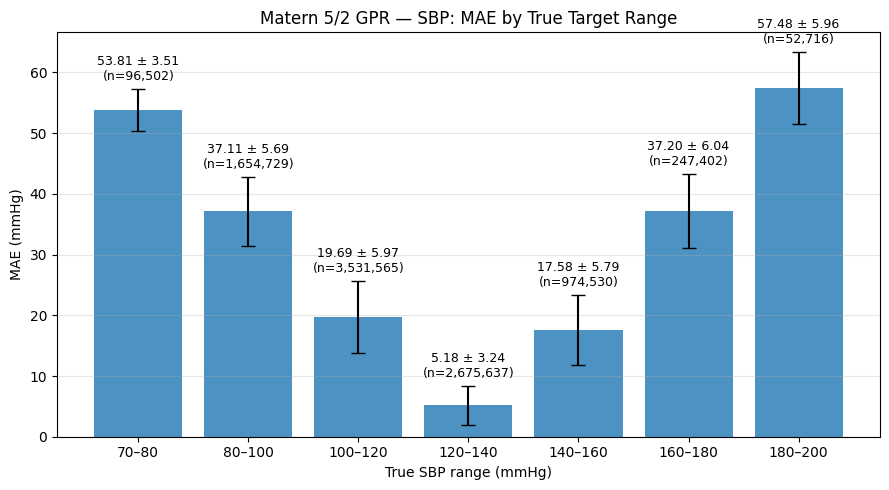

In [28]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 19.534766547669488

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 105,176 samples...
RMSE: 20.6099
MSE : 424.7686
R²  : 0.1953
MAE : 16.2073


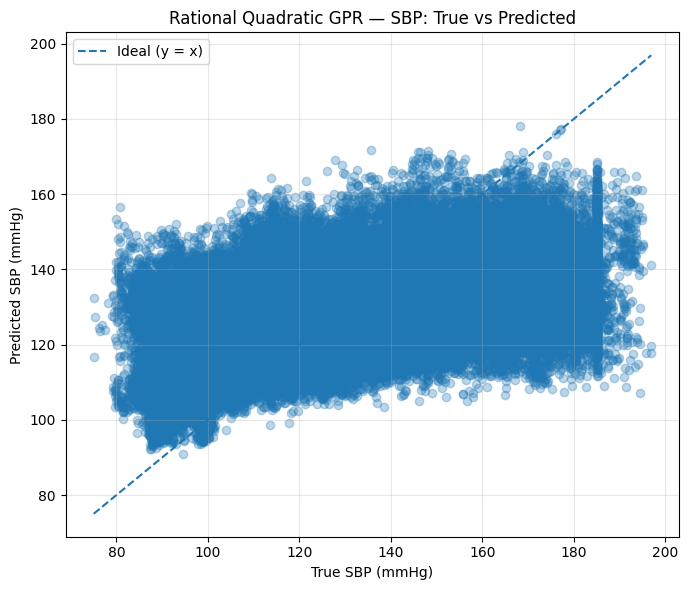

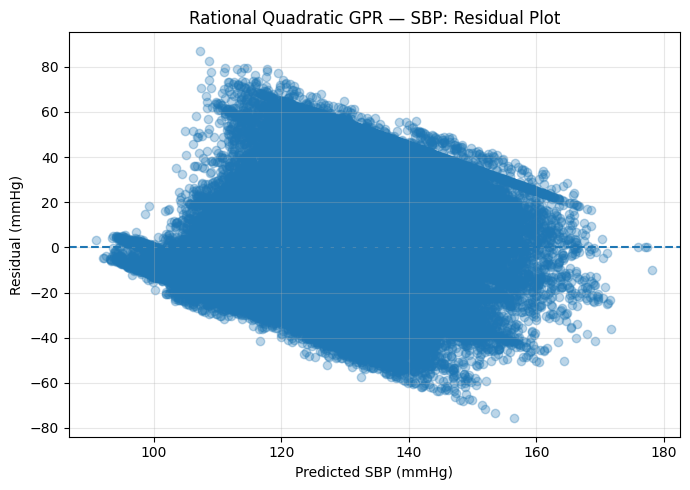

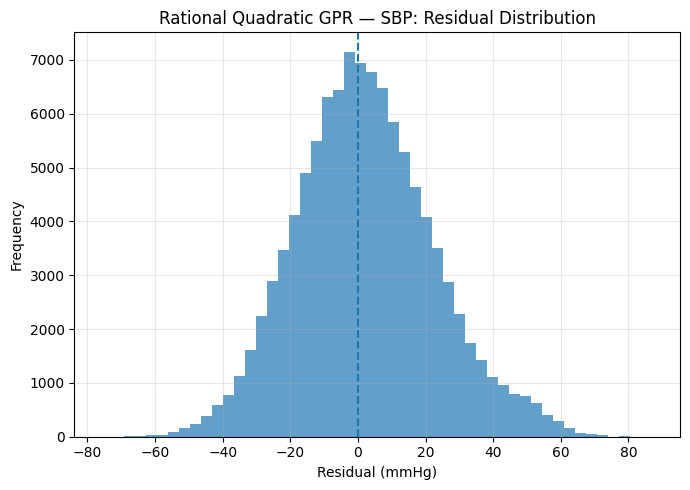

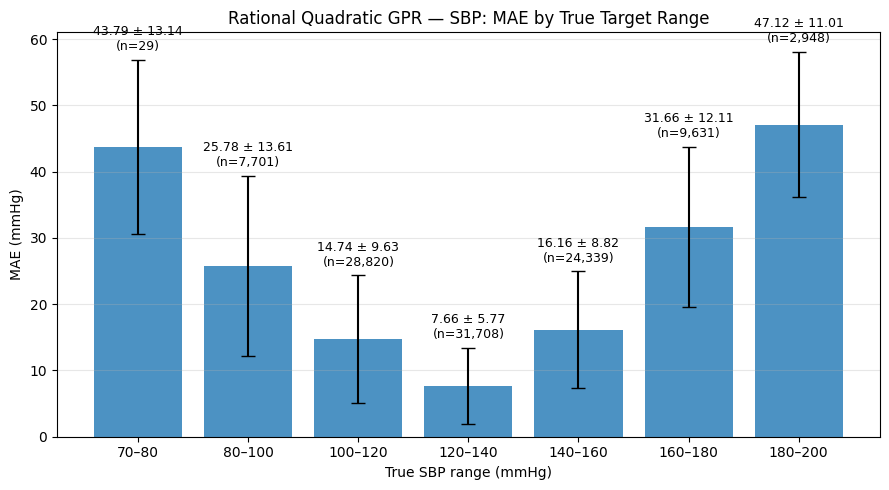

In [29]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 22.6421
MSE : 512.6665
R²  : -0.1995
MAE : 18.4207


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


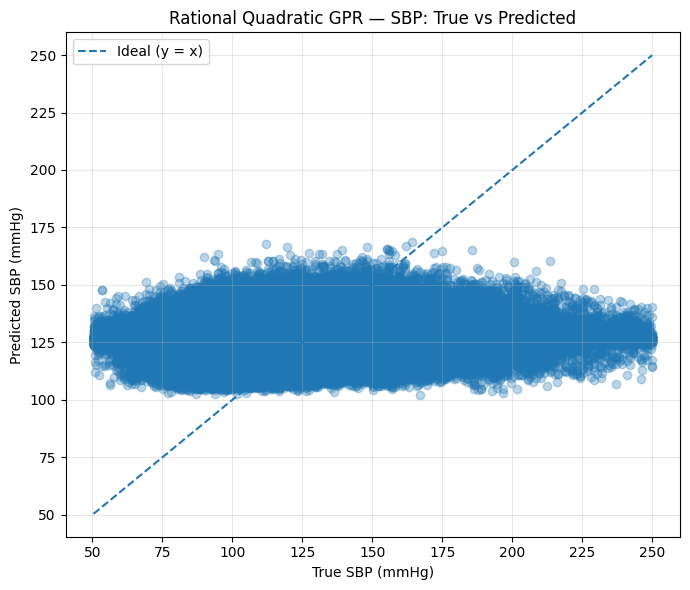

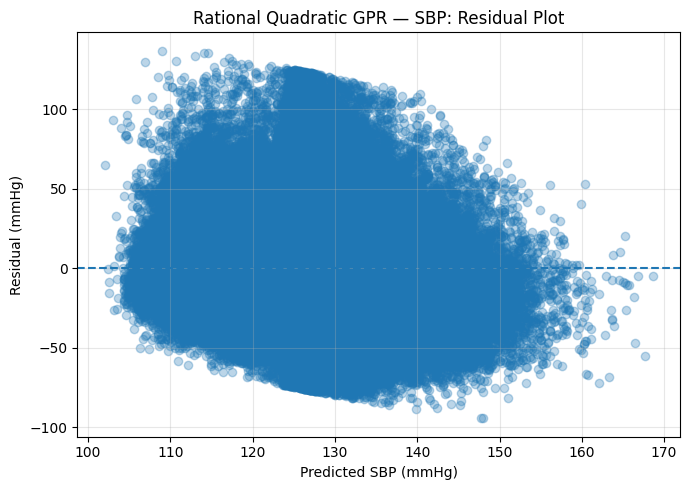

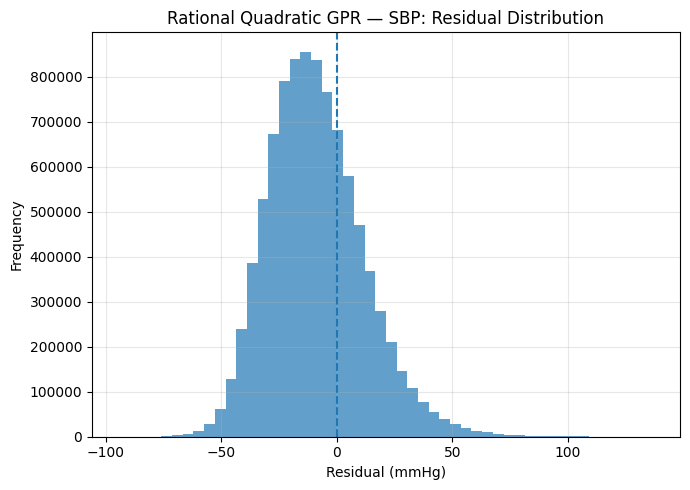

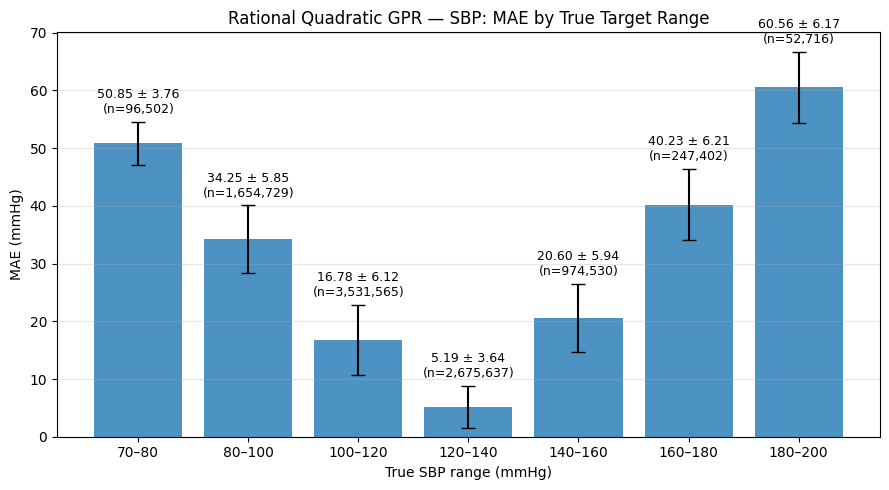

In [30]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 256, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}

Best CV RMSE: 20.586884746875892

Best ANN / MLP model:
MLPRegressor(batch_size=256, early_stopping=True, hidden_layer_sizes=(64, 32),
             max_iter=300, n_iter_no_change=20, random_state=42)

Starting batched prediction on 105,176 samples...
Processed 10,000 / 105,176
Processed 20,000 / 105,176
Processed 30,000 / 105,176
Processed 40,000 / 105,176
Processed 50,000 / 105,176
Processed 60,000 / 105,176
Processed 70,000 / 105,176
Processed 80,000 / 105,176
Processed 90,000 / 105,176
Processed 100,000 / 105,176
Processed 105,176 / 105,176

ANN / MLP Regressor — SBP
------------------------------------
RMSE: 21.0469
MSE : 442.9728
R²  : 0.1608
MAE : 16.5792


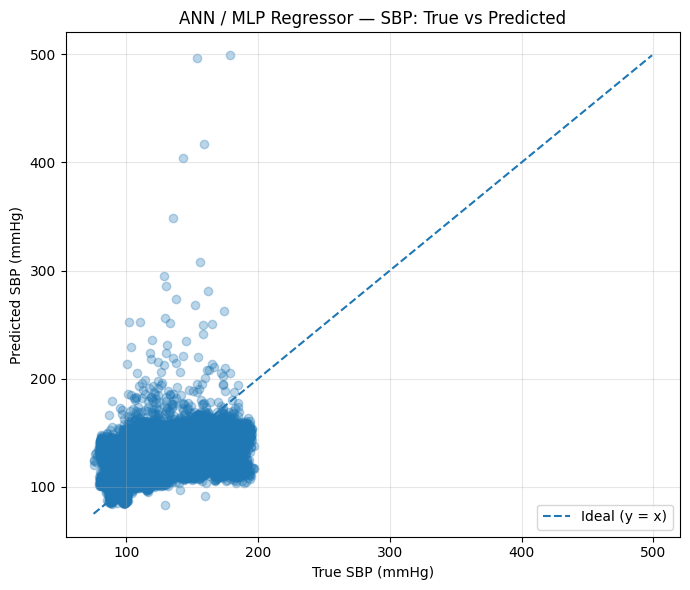

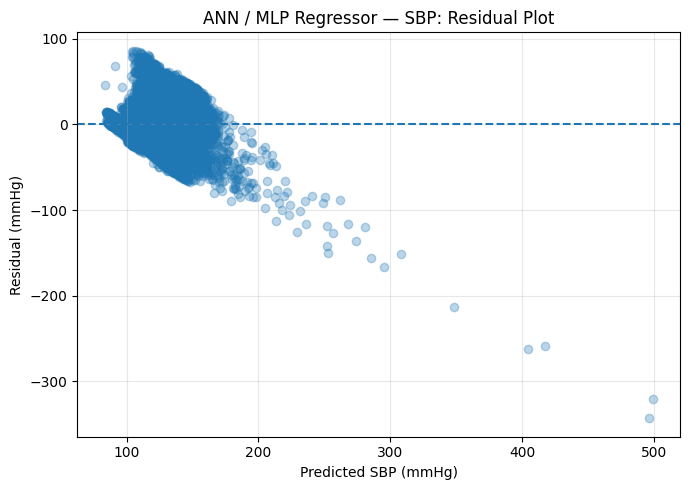

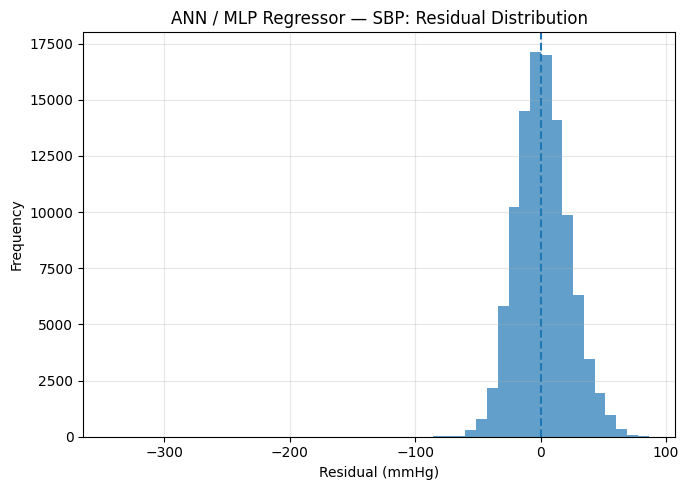

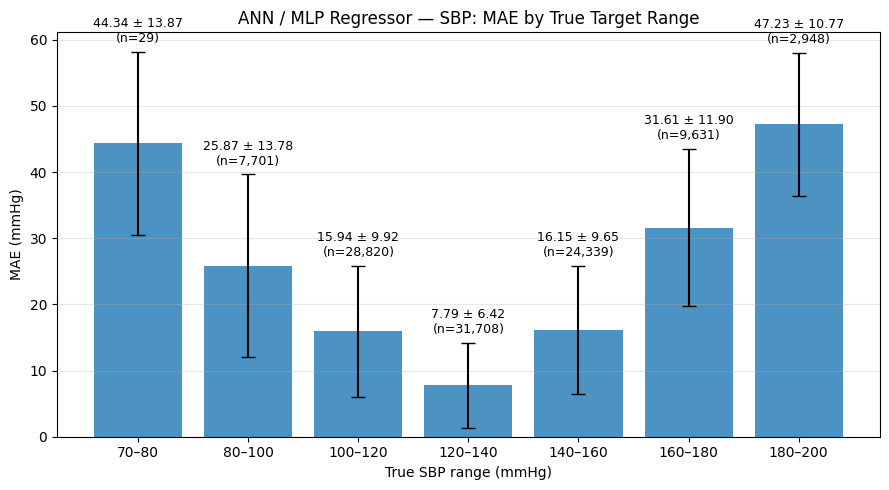

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 479.8891
MSE : 230293.5464
R²  : -537.8216
MAE : 192.6672


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


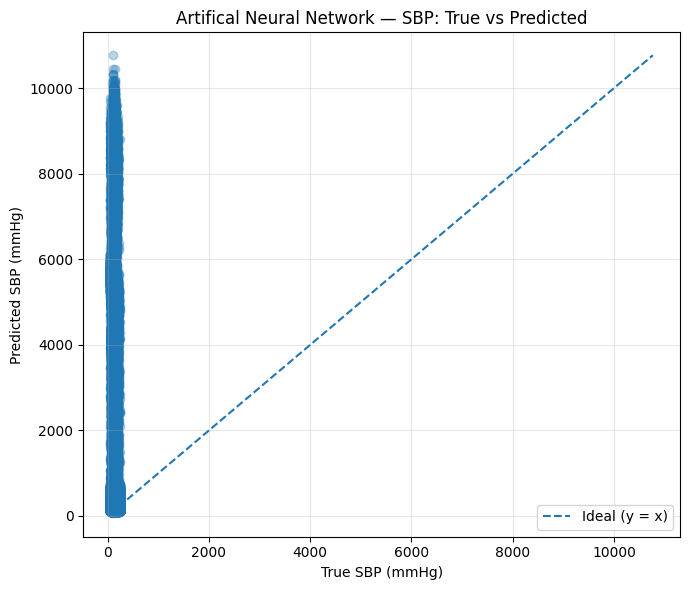

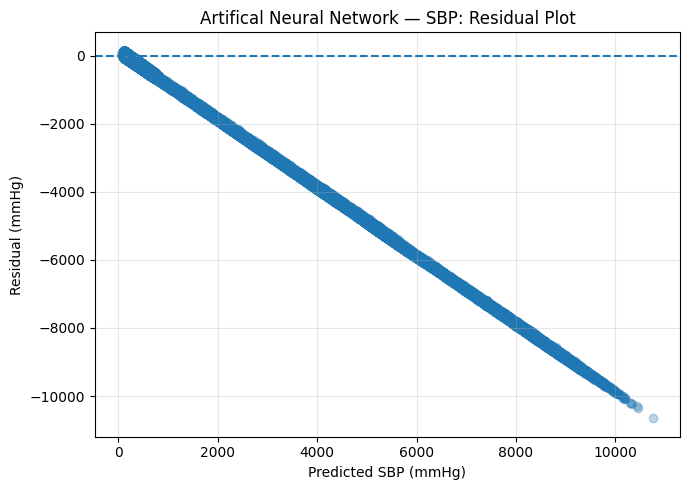

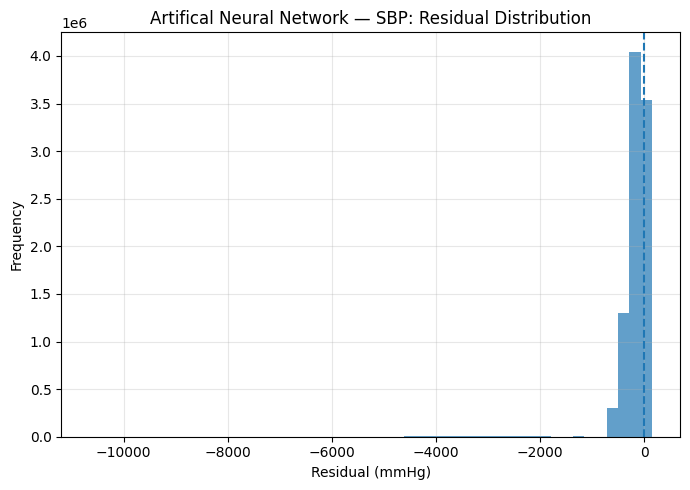

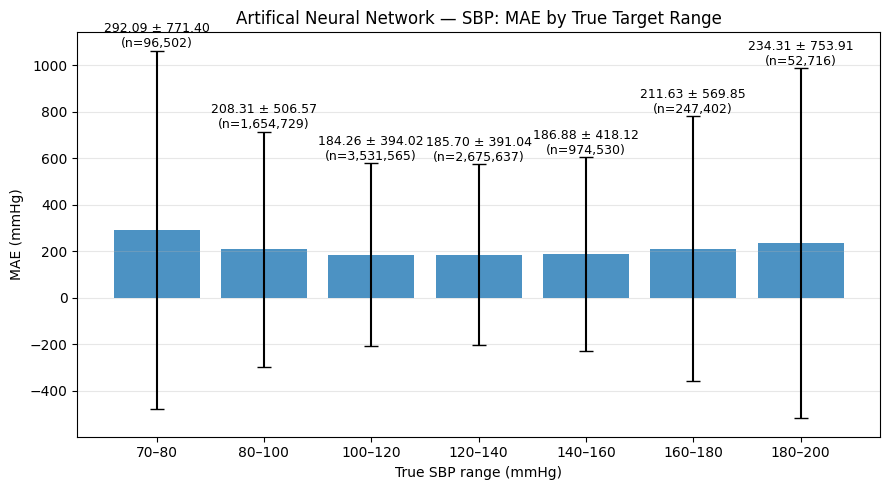

In [32]:
y_pred_vitaldb = predict_gpr_in_batches(
    ann_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)